# I. 준비과정
- df를 타겟 ETF 11개의 수익률을 저장하도록 변경함(v3)

In [ ]:
# TVAESynthesizer 라이브러리 사용을 위한 sdv 모듈 인스톨, 백테스팅을 위한 bt 모듈 인스톨
!pip install sdv
!pip install bt

In [ ]:
# 필요 라이브러리 import
import pandas as pd
import numpy as np
import random
import itertools
import matplotlib.pyplot as plt
import bt
import yfinance as yf
from sdv.metadata import SingleTableMetadata
from sdv.single_table import TVAESynthesizer
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import entropy
from scipy.stats import linregress
from scipy.optimize import minimize

In [ ]:
# ETF 수익률 데이터 불러오는 작업
def get_daily_returns(ticker, start_date, end_date):
    etf_data = yf.download(ticker, start = start_date, end = end_date, interval = '1d')

    x = etf_data['Close'].pct_change().dropna() # 종가 데이터를 기반으로 수익률을 계산함

    x.name = 'Return'

    return x

ticker_list = ['IWM', 'SPY', 'VTV', 'VUG', 'MTUM', 'QUAL', 'VYMI', 'USMV', 'KBE', 'IYK', 'IYC']

start_date = '1990-01-01'
end_date = '2024-11-20'

returns_list = [] # 각 ETF 수익률 데이터 저장할 리스트

for ticker in ticker_list:
    daily_returns = get_daily_returns(ticker, start_date, end_date)
    returns_list.append(daily_returns)

df = pd.concat(returns_list, axis = 1)
df.index = pd.to_datetime(df.index).strftime('%Y-%m-%d')
df.columns = ticker_list

print(df.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                 IWM       SPY       VTV       VUG      MTUM      QUAL  \
Date                                                                     
2024-11-13 -0.009896  0.000486  0.001294 -0.000440 -0.002541 -0.002445   
2024-11-14 -0.013483 -0.006430 -0.007079 -0.006094 -0.010332 -0.005827   
2024-11-15 -0.014918 -0.012809 -0.003395 -0.020437 -0.006531 -0.016379   
2024-11-18  0.001970  0.004097  0.004599  0.004550  0.004798  0.002339   
2024-11-19  0.007426  0.003655 -0.003899  0.010384  0.007545  0.002334   

                VYMI      USMV       KBE       IYK       IYC  
Date                                                          
2024-11-13 -0.004164  0.000000 -0.007395  0.002632  0.007750  
2024-11-14  0.002018 -0.010844 -0.008113 -0.000437 -0.005899  
2024-11-15  0.003022 -0.010637  0.000835 -0.009045 -0.009537  
2024-11-18  0.008177  0.003730 -0.001501  0.007655  0.004814  
2024-11-19 -0.002277 -0.001312 -0.004677 -0.001169  0.003620  


# II. KL-Divergence 계산 함수

In [ ]:
def calculateKLDivergence(p, q, bins = 50):
    # 두 데이터의 히스토그램 계산 (확률분포로 변환)
    p_hist, bin_edges = np.histogram(p, bins = bins, density = True)
    q_hist, _ = np.histogram(q, bins=bin_edges, density = True)

    # 히스토그램 값이 0인 경우 처리 (KL-Divergence 정의 상 log(0) 계산 방지)
    p_hist = np.where(p_hist == 0, 1e-10, p_hist)
    q_hist = np.where(q_hist == 0, 1e-10, q_hist)

    # KL-Divergence 계산
    return entropy(p_hist, q_hist)

# III. 페어트레이딩할 ETF 수익률 데이터 생성하는 함수

### 1. 그래프의 x축은 수익률 수치, y축은 수익률의 밀도(발생확률)

<br>

### 2. 원본 수익률 데이터와 VAE로 생성된 수익률 데이터의 수치 차이 요인
-> 차이가 나는 원인은 VAE의 본질적인 특성과 학습 설정 문제 때문일 가능성이 높음.

- ChatGPT 질문 결과, 원본 수익률 데이터를 '정규화'하여 집어넣으면 생성 데이터와 원본 데이터의 차이를 그나마 줄일 수 있다고 함. 아래는 정규화 적용 코드임. (수익률은 따로 로그변환, 차분 필요 없다고 이해하고 작성)
  - 정규화 작업 진행해도 되나요?

<br>


### 3. 생성된 두 주식 쌍의 분포를 파악하고, KL-Divergence 값을 계산하기 위해 '표준화' 수행
- 표준화 작업 진행해도 되나요?

<br>

### 4. 원본 데이터쌍과 생성된 데이터쌍의 분포 및 KL-Divergence 비교 시각화

In [ ]:
def generateETFReturns():
    # 페어 트레이딩 조합 생성
    ticker_combinations = list(itertools.combinations(ticker_list, 2))
    print("\n페어트레이딩 가능한 ETF 조합 수량 :", len(ticker_combinations))

    # 정규화 객체 생성
    scaler = MinMaxScaler(feature_range = (0, 1))

    for ticker1, ticker2 in ticker_combinations:
        # 원본 데이터 준비 (각 ETF에 해당하는 수익률)
        etf1 = df[ticker1].dropna().reset_index(drop = True)
        etf2 = df[ticker2].dropna().reset_index(drop = True)

        # 정규화
        normed_etf1 = etf1.copy()
        normed_etf2 = etf2.copy()
        normed_etf1 = scaler.fit_transform(normed_etf1.values.reshape(-1, 1))
        normed_etf2 = scaler.fit_transform(normed_etf2.values.reshape(-1, 1))

        # VAE 학습 및 데이터 생성
        etf_metadata1 = SingleTableMetadata()
        etf_metadata1.detect_from_dataframe(data = pd.DataFrame(normed_etf1, columns = ['returns']))
        synthesizer1 = TVAESynthesizer(metadata = etf_metadata1)
        synthesizer1.fit(pd.DataFrame(normed_etf1, columns = ['returns']))
        gen_returns1 = synthesizer1.sample(num_rows = len(etf1))['returns']

        etf_metadata2 = SingleTableMetadata()
        etf_metadata2.detect_from_dataframe(data = pd.DataFrame(normed_etf2, columns = ['returns']))
        synthesizer2 = TVAESynthesizer(metadata = etf_metadata2)
        synthesizer2.fit(pd.DataFrame(normed_etf2, columns = ['returns']))
        gen_returns2 = synthesizer2.sample(num_rows = len(etf2))['returns']

        # 생성된 두 ETF 분포를 비교 및 KL-Divergence 값 계산을 위해 표준화
        gen_returns1 = (gen_returns1 - gen_returns1.mean()) / gen_returns1.std()
        gen_returns2 = (gen_returns2 - gen_returns2.mean()) / gen_returns2.std()

        # KL-Divergence 계산
        kl_original = calculateKLDivergence(etf1, etf2)
        kl_generated = calculateKLDivergence(gen_returns1, gen_returns2)

        # 데이터 분포 시각화
        plt.figure(figsize = (12, 6))

        # 원본 데이터 (etf1 vs etf2) 분포
        plt.subplot(2, 2, 1)
        plt.hist(etf1, bins = 50, alpha = 0.7, label = f'{ticker1} (Original)', density = True)
        plt.hist(etf2, bins = 50, alpha = 0.7, label = f'{ticker2} (Original)', density = True)
        plt.title(f'Distribution of Original Data\n{ticker1} vs. {ticker2}')
        plt.legend()

        # 생성 데이터 (gen_etf1 vs gen_etf2) 분포
        plt.subplot(2, 2, 2)
        plt.hist(gen_returns1, bins = 50, alpha = 0.7, label = f'{ticker1} (Generated)', density = True)
        plt.hist(gen_returns2, bins = 50, alpha = 0.7, label = f'{ticker2} (Generated)', density = True)
        plt.title(f'Distribution of Generated Data\n{ticker1} vs. {ticker2}')
        plt.legend()

        # KL-Divergence 막대 그래프 시각화
        plt.subplot(2, 2, 3)
        plt.bar(['Original', 'Generated'], [kl_original, kl_generated], color = ['blue', 'orange'])
        plt.title(f'KL-Divergence Between {ticker1} and {ticker2}')
        plt.ylabel('KL-Divergence')
        plt.xticks(rotation = 45)


        # 상관관계 분석 그래프 시각화(날짜기준 inner join 후 수행)
        retf1 = df[ticker1].dropna()
        retf2 = df[ticker2].dropna()
        regrlist = pd.concat([retf1, retf2], axis = 1, join = 'inner')
        regrlist.columns = [ticker1, ticker2]
        regr = linregress(regrlist[ticker1], regrlist[ticker2])
        regr_line = f"Y = {regr.slope : .2f} * X + {regr.intercept : .2f}"
        plt.subplot(2, 2, 4)
        plt.plot(regrlist[ticker1], regrlist[ticker2], '.')
        plt.plot(regrlist[ticker1], regr.slope * regrlist[ticker1] + regr.intercept, 'r')
        plt.legend([f'{ticker1} x {ticker2}', regr_line])
        plt.title(f'{ticker1} x {ticker2} Correlation (R = {regr.rvalue:.2f})')
        plt.xlabel(f'{ticker1}')
        plt.ylabel(f'{ticker2}')


        # 결과 출력
        print(f"Original ETF Pair's KL-Divergence between {ticker1} and {ticker2} : {kl_original}")
        print(f"Generated ETF Pair's KL-Divergence between {ticker1} and {ticker2} : {kl_generated}")

        plt.tight_layout()
        plt.show()

        # 원본 ETF 데이터 쌍의 KL-Divergence 값을 저장
        KLD_list.append([[ticker1, ticker2], kl_original])

    # KL-Divergence 리스트 출력
    print(KLD_list)

# IV. 메인 함수

### IWM : 소형주 ETF
### SPY : 대형주 ETF
### VTV : 가치주 ETF
### VUG : 성장주 ETF
### MTUM : 모멘텀 ETF
### QUAL : 재무건전성 ETF
### VYMI : 배당주 ETF
### USMV : 저변동성 ETF
### KBE : 은행주 ETF
### IYK : 필수소비재(경기방어재) ETF
### IYC : 경기소비재 ETF


페어트레이딩 가능한 ETF 조합 수량 : 55


/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and SPY : 0.10485143427015396
Generated ETF Pair's KL-Divergence between IWM and SPY : 0.04447837474440028


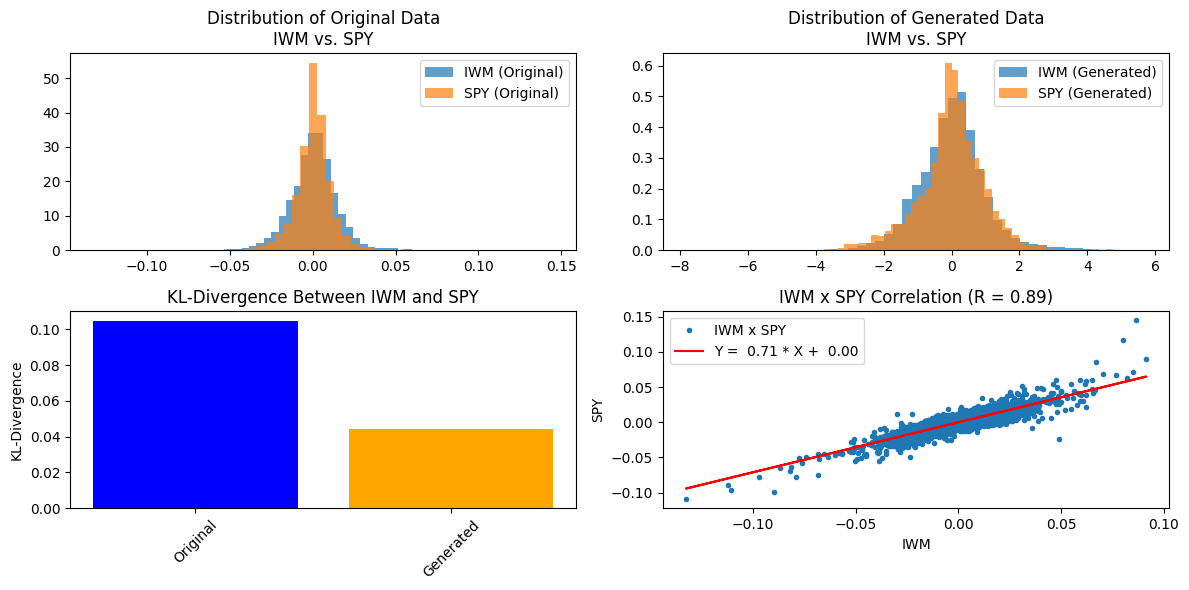

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and VTV : 0.1182067712280523
Generated ETF Pair's KL-Divergence between IWM and VTV : 0.0438735748499875


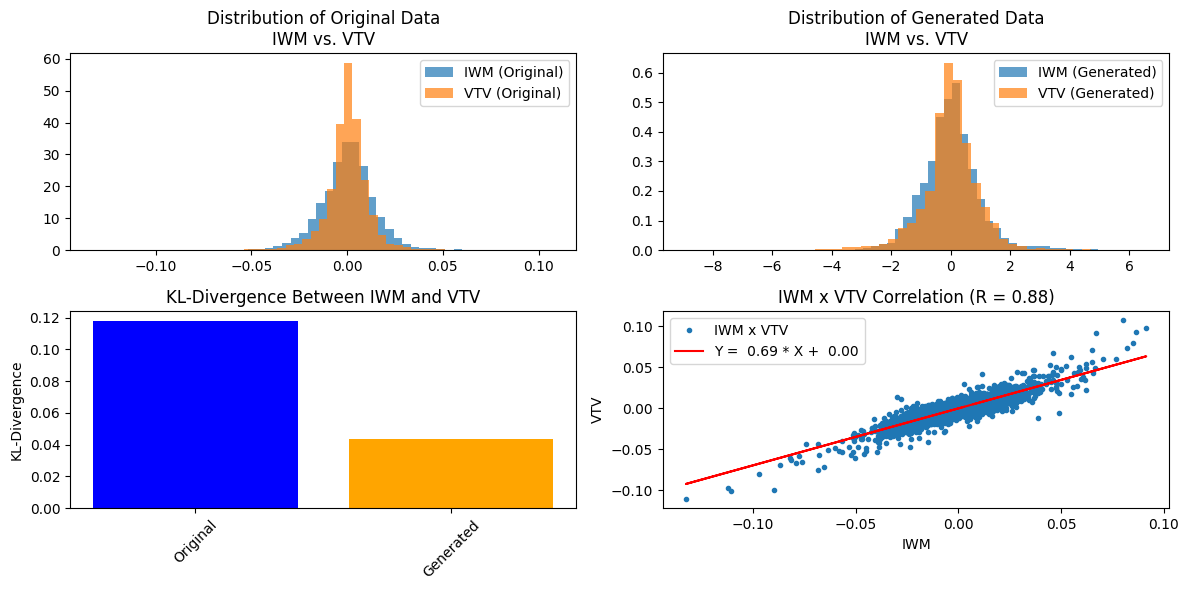

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and VUG : 0.08645892928916452
Generated ETF Pair's KL-Divergence between IWM and VUG : 0.07296807870778496


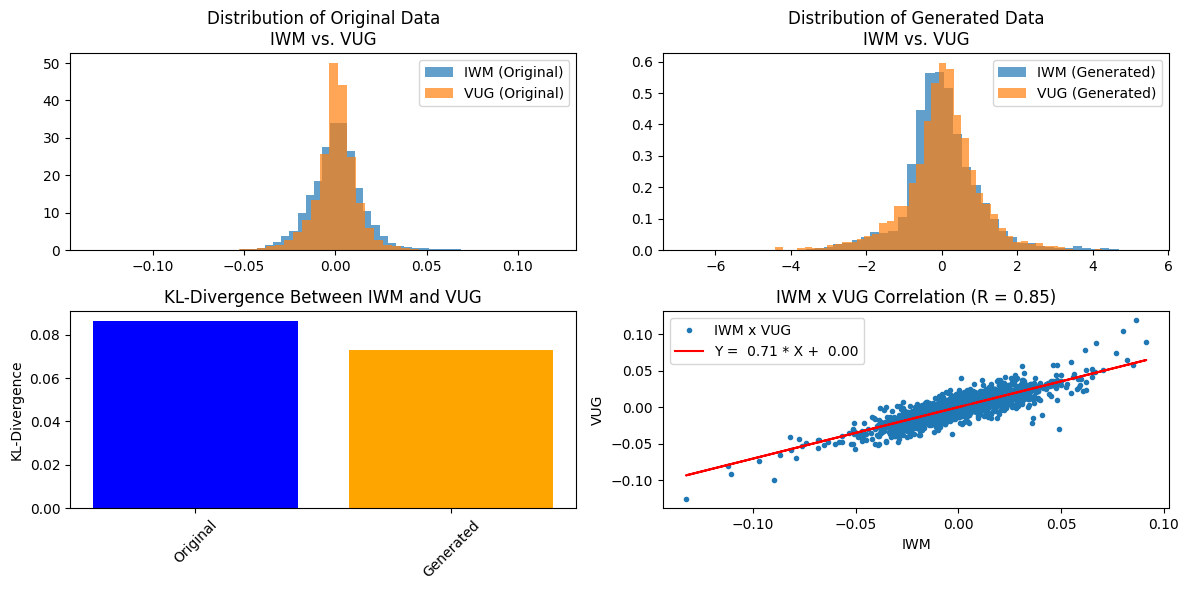

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and MTUM : 0.1364647719204022
Generated ETF Pair's KL-Divergence between IWM and MTUM : 0.06874220006117392


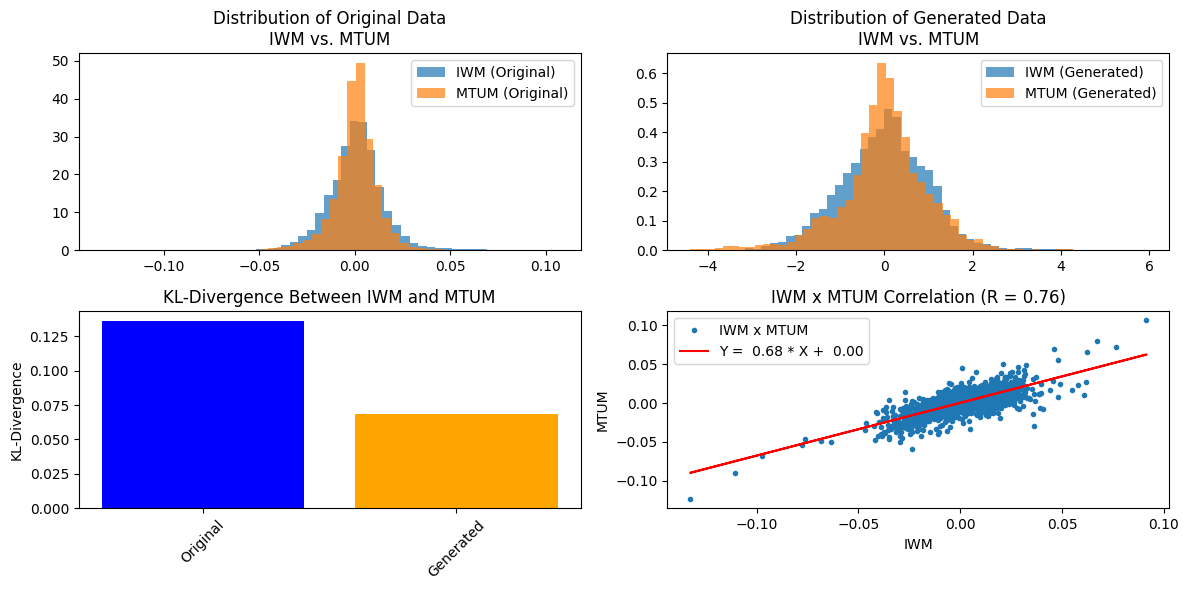

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and QUAL : 0.18520076418401113
Generated ETF Pair's KL-Divergence between IWM and QUAL : 0.10007901855835373


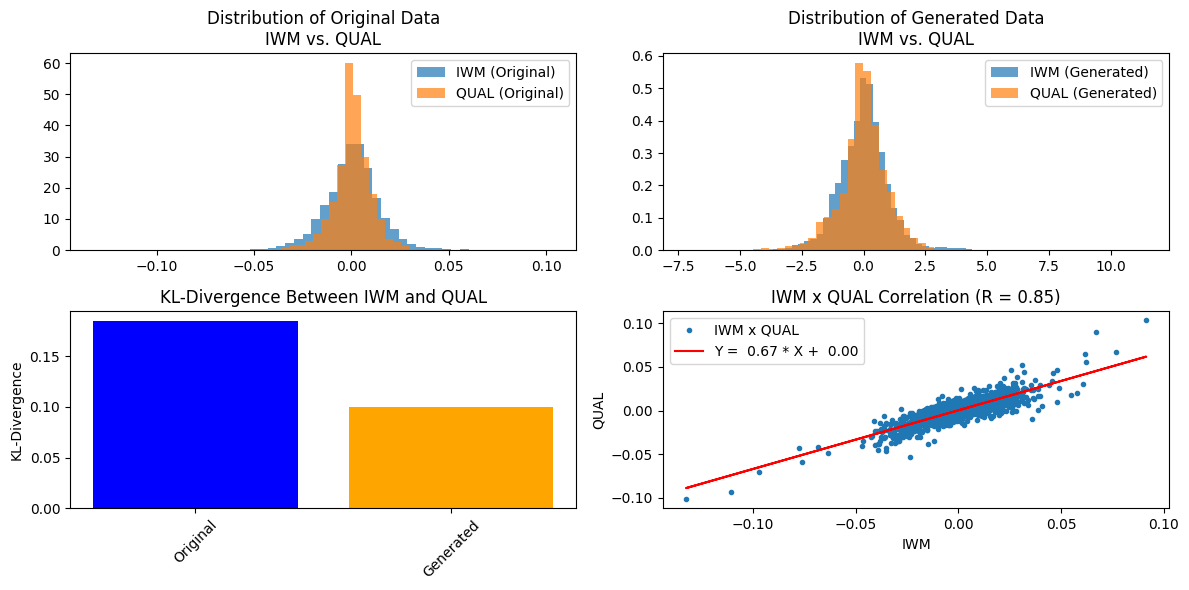

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and VYMI : 0.31618727754297404
Generated ETF Pair's KL-Divergence between IWM and VYMI : 0.11940890610074198


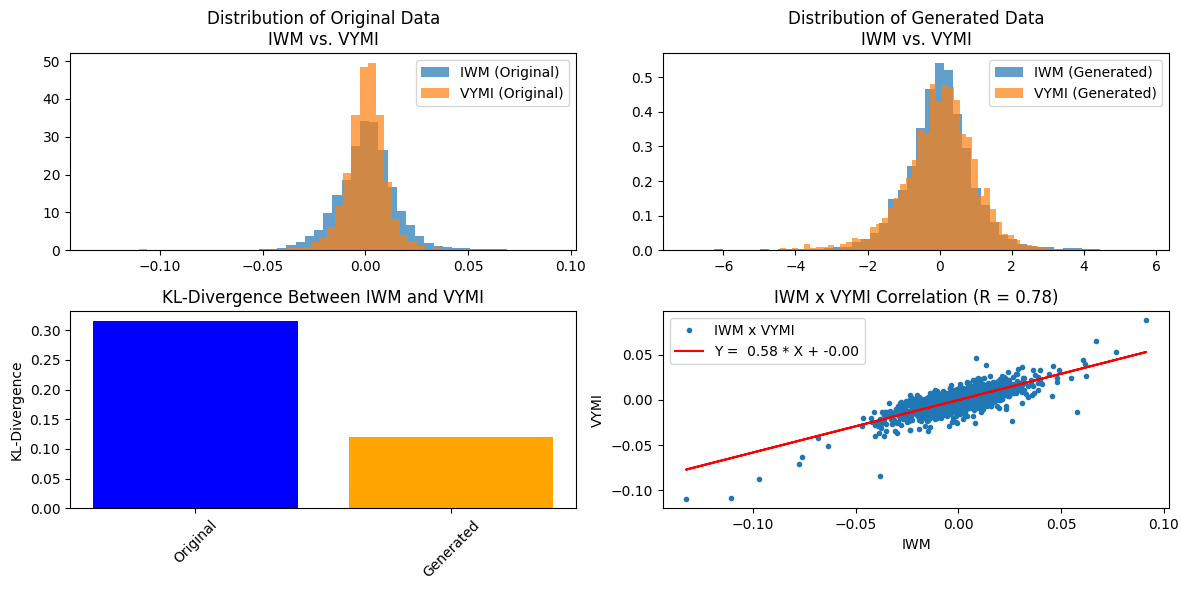

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and USMV : 0.5326869320071261
Generated ETF Pair's KL-Divergence between IWM and USMV : 0.07314382244622902


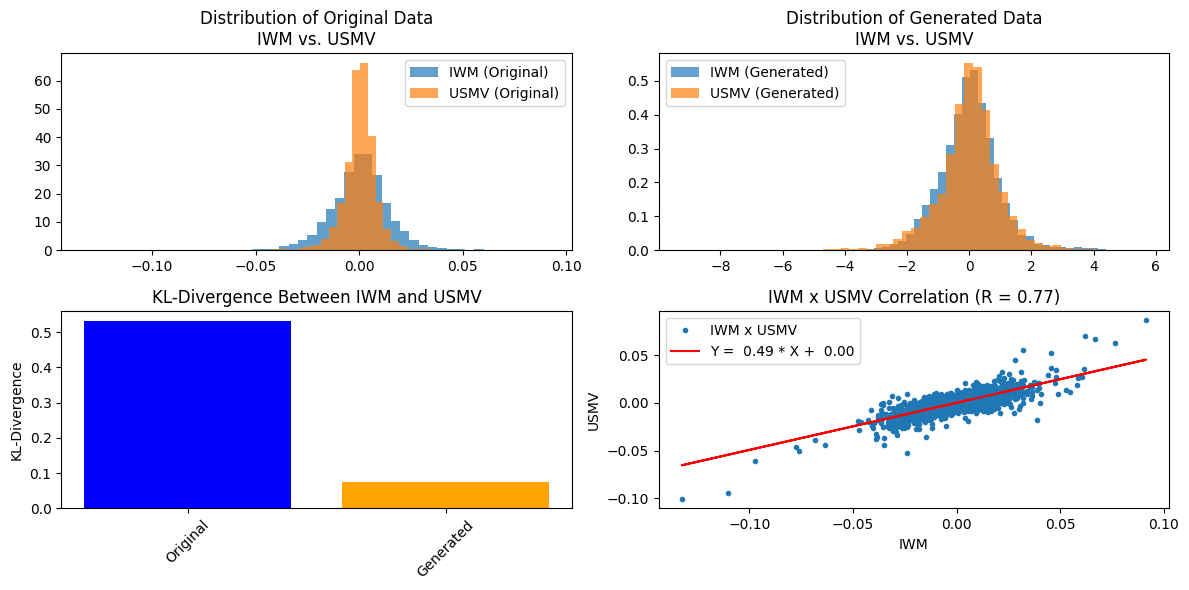

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and KBE : 0.029099916090092645
Generated ETF Pair's KL-Divergence between IWM and KBE : 0.0478751803295847


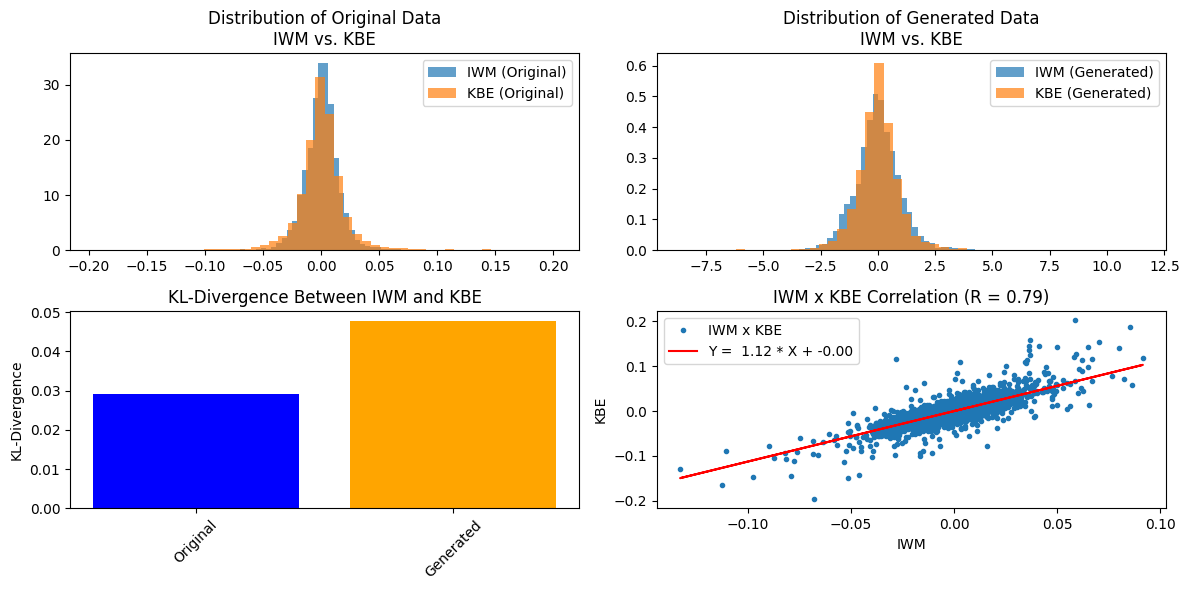

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and IYK : 0.20714479803943828
Generated ETF Pair's KL-Divergence between IWM and IYK : 0.04714686855436391


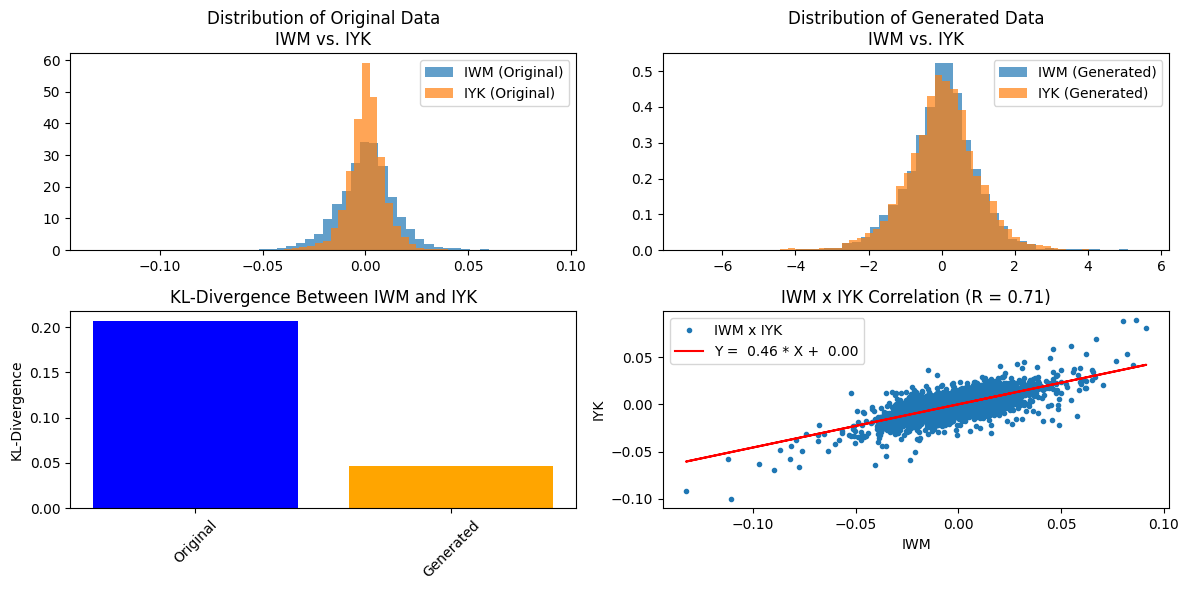

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IWM and IYC : 0.09150164551976726
Generated ETF Pair's KL-Divergence between IWM and IYC : 0.03257511127867304


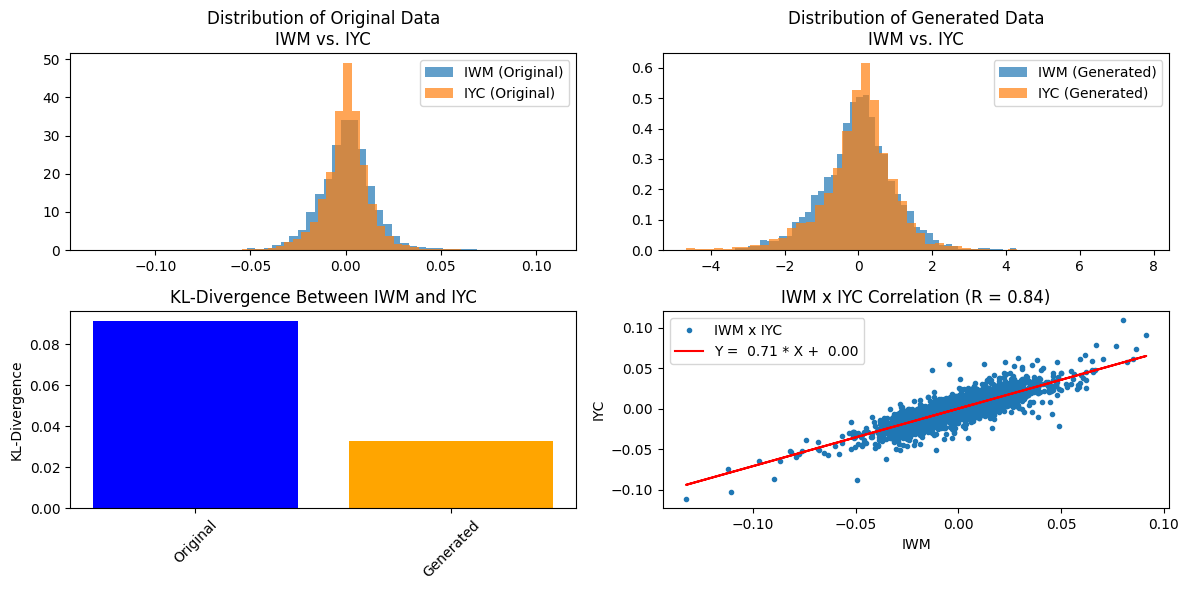

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between SPY and VTV : 0.01868743862950714
Generated ETF Pair's KL-Divergence between SPY and VTV : 0.042079215379430525


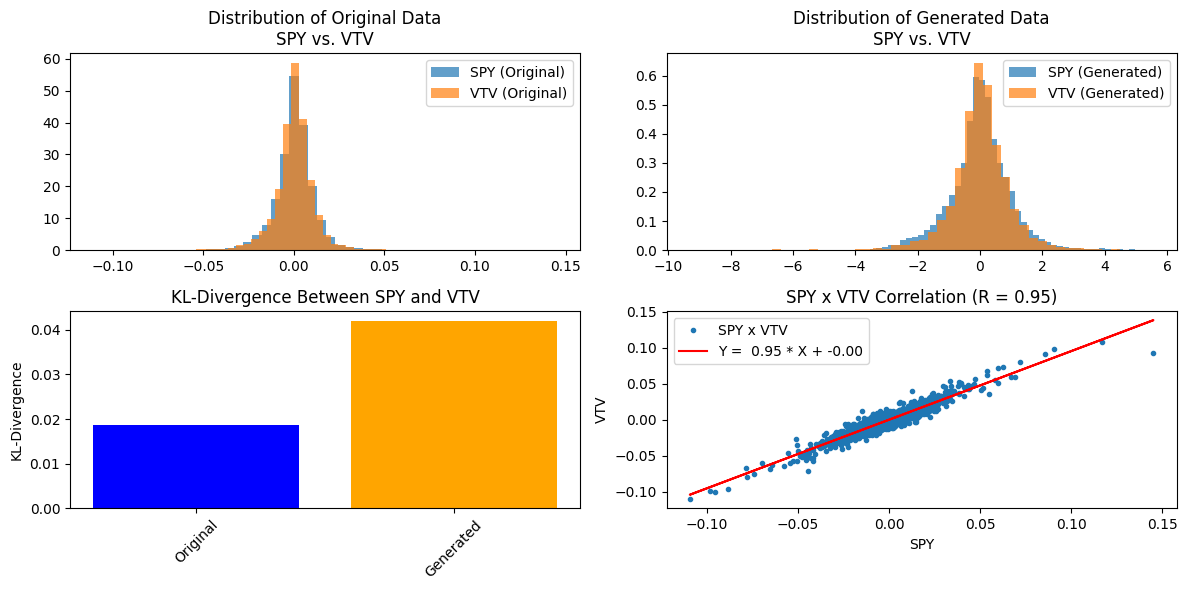

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between SPY and VUG : 0.020760487500874336
Generated ETF Pair's KL-Divergence between SPY and VUG : 0.10058270013132192


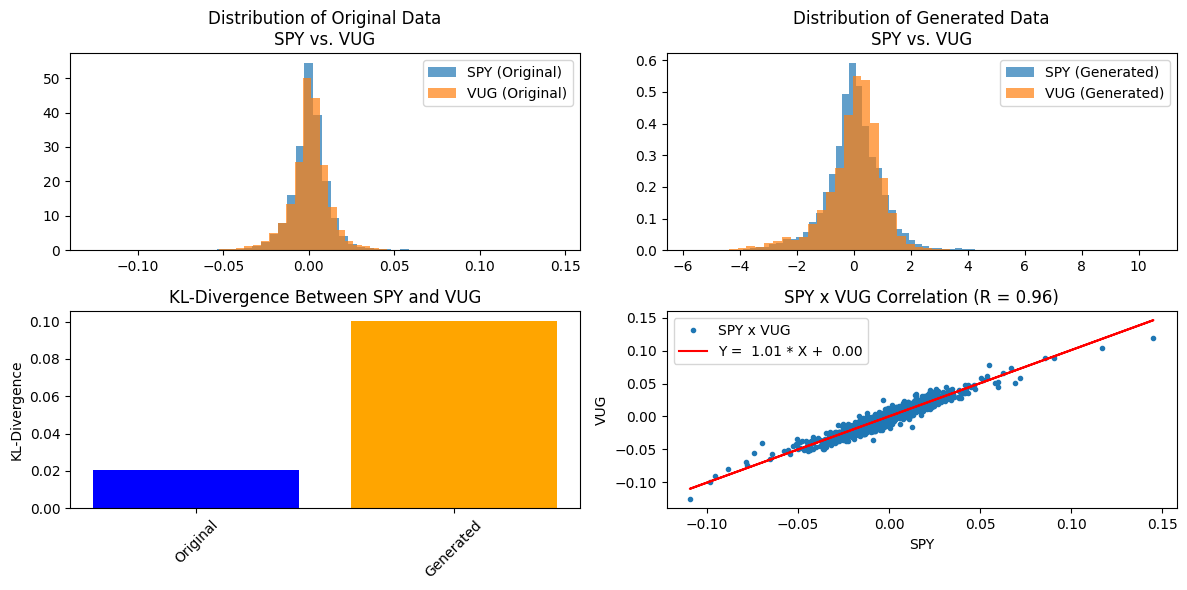

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between SPY and MTUM : 0.04790132436036458
Generated ETF Pair's KL-Divergence between SPY and MTUM : 0.06283555977743564


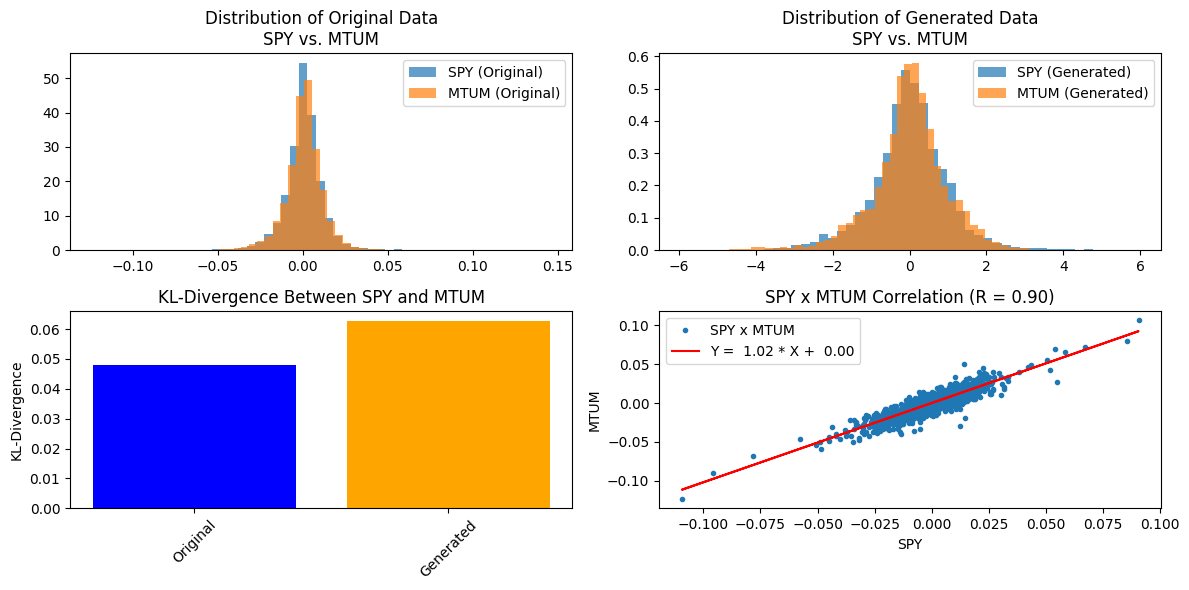

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between SPY and QUAL : 0.05942971369046535
Generated ETF Pair's KL-Divergence between SPY and QUAL : 0.08600839688234571


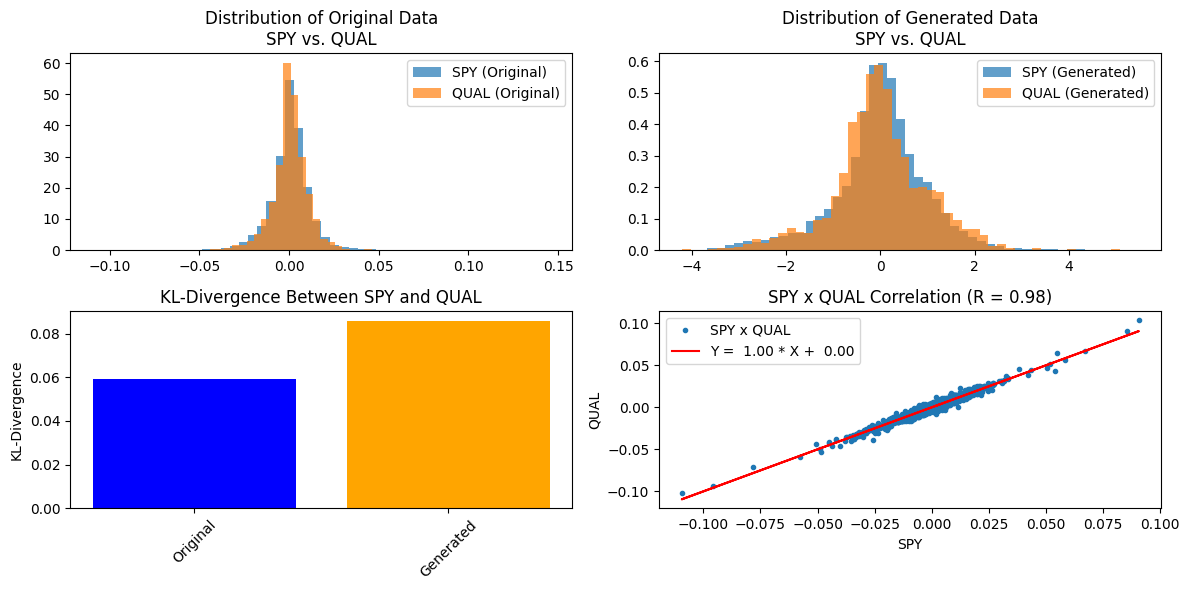

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between SPY and VYMI : 0.09350779944885718
Generated ETF Pair's KL-Divergence between SPY and VYMI : 0.09933847145190959


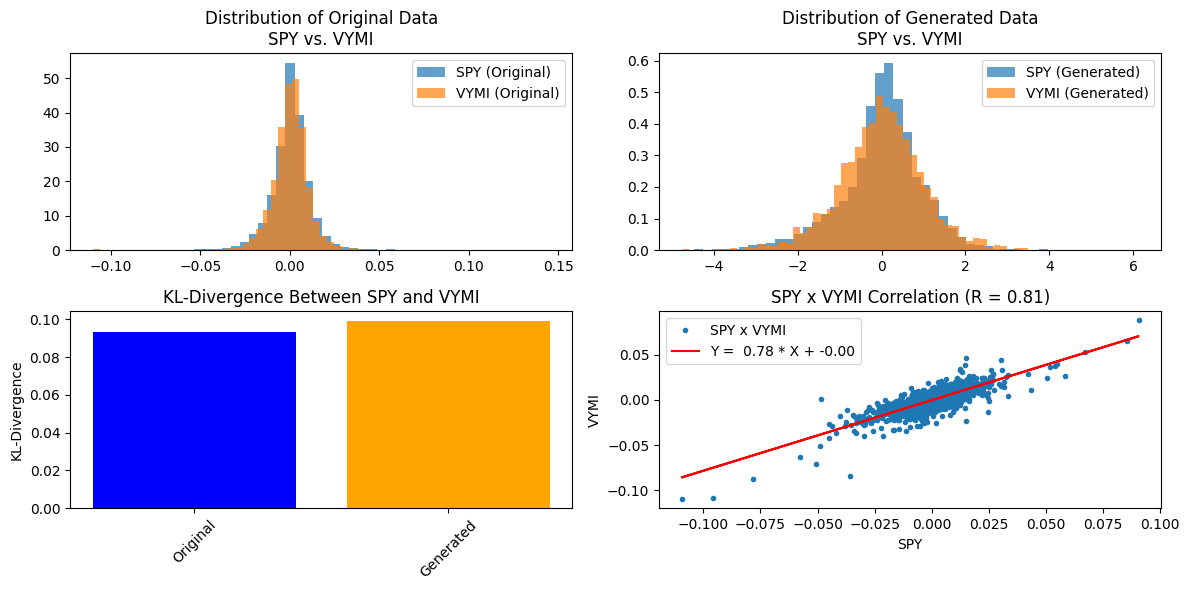

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between SPY and USMV : 0.15891644458392132
Generated ETF Pair's KL-Divergence between SPY and USMV : 0.04411228701996082


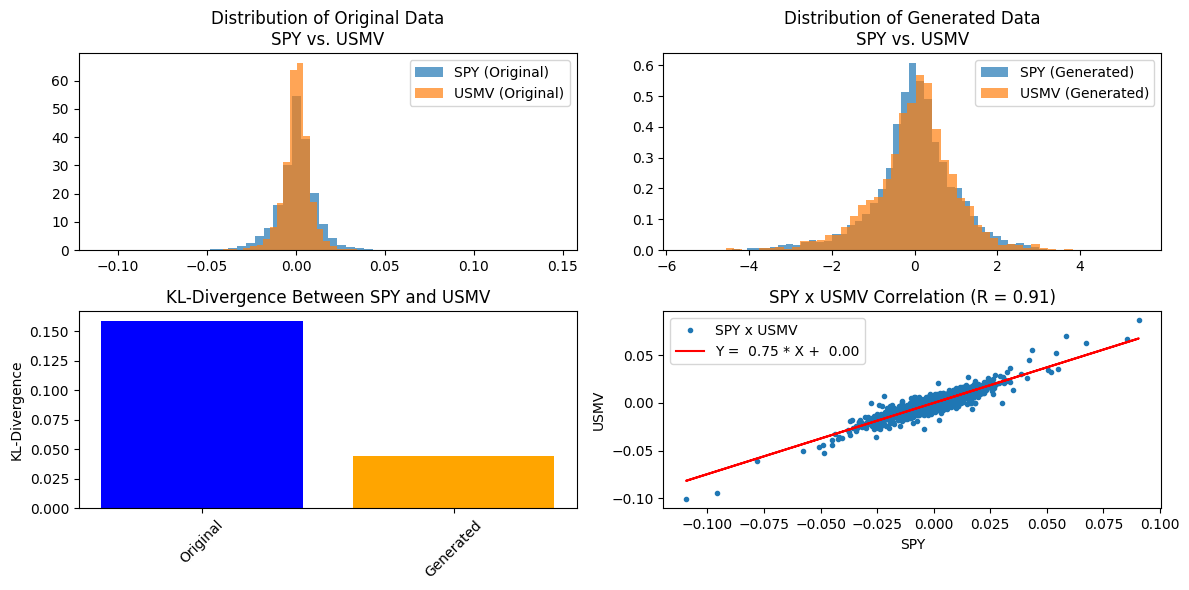

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between SPY and KBE : 0.1167853137127603
Generated ETF Pair's KL-Divergence between SPY and KBE : 0.040721432223660065


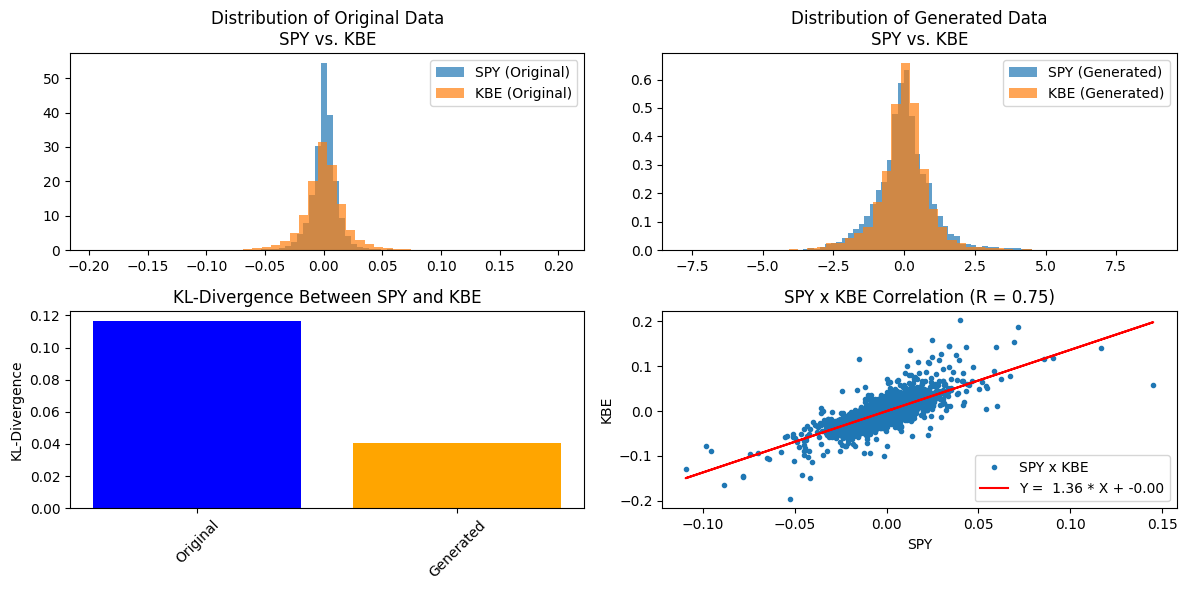

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between SPY and IYK : 0.04256555372442425
Generated ETF Pair's KL-Divergence between SPY and IYK : 0.0309622417983827


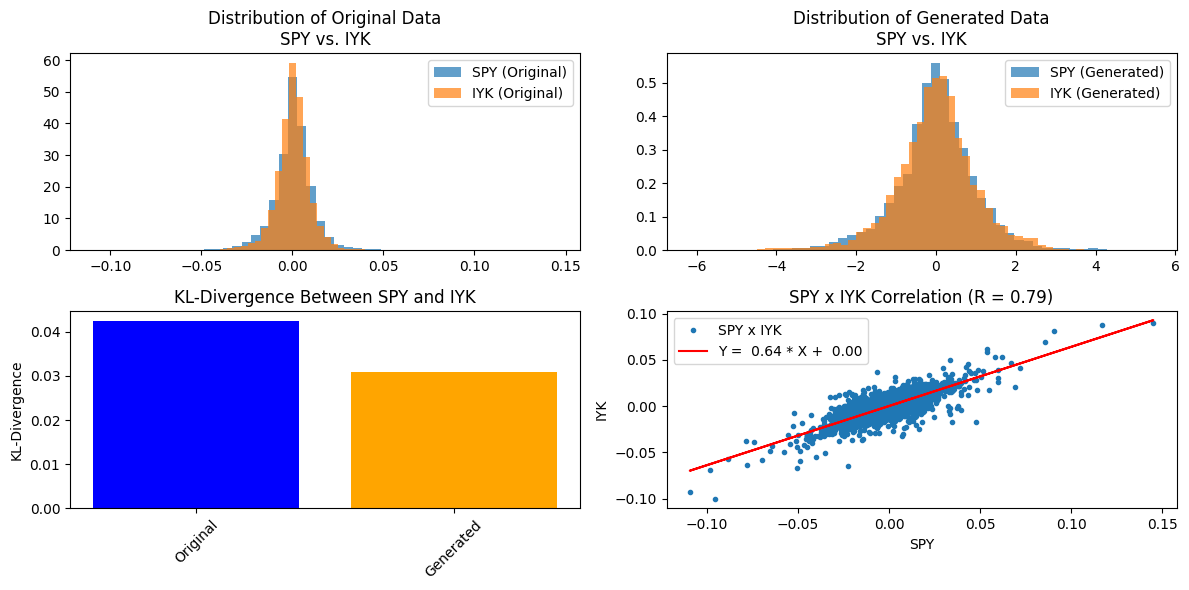

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between SPY and IYC : 0.03014735779675616
Generated ETF Pair's KL-Divergence between SPY and IYC : 0.03423743922368899


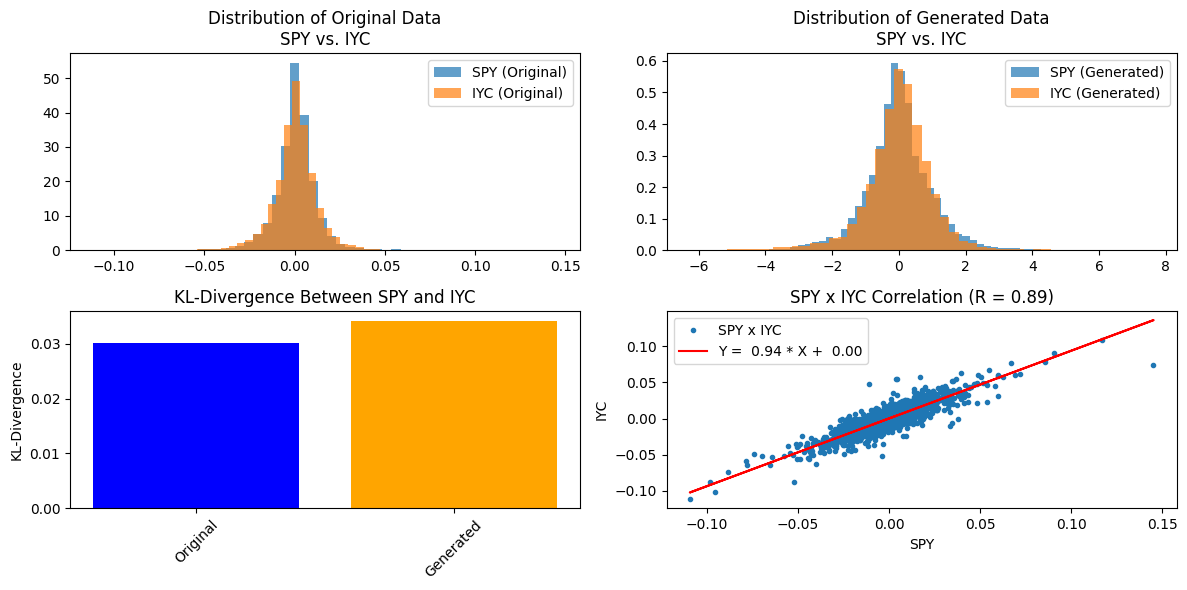

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VTV and VUG : 0.04182785932353723
Generated ETF Pair's KL-Divergence between VTV and VUG : 0.05893156743772407


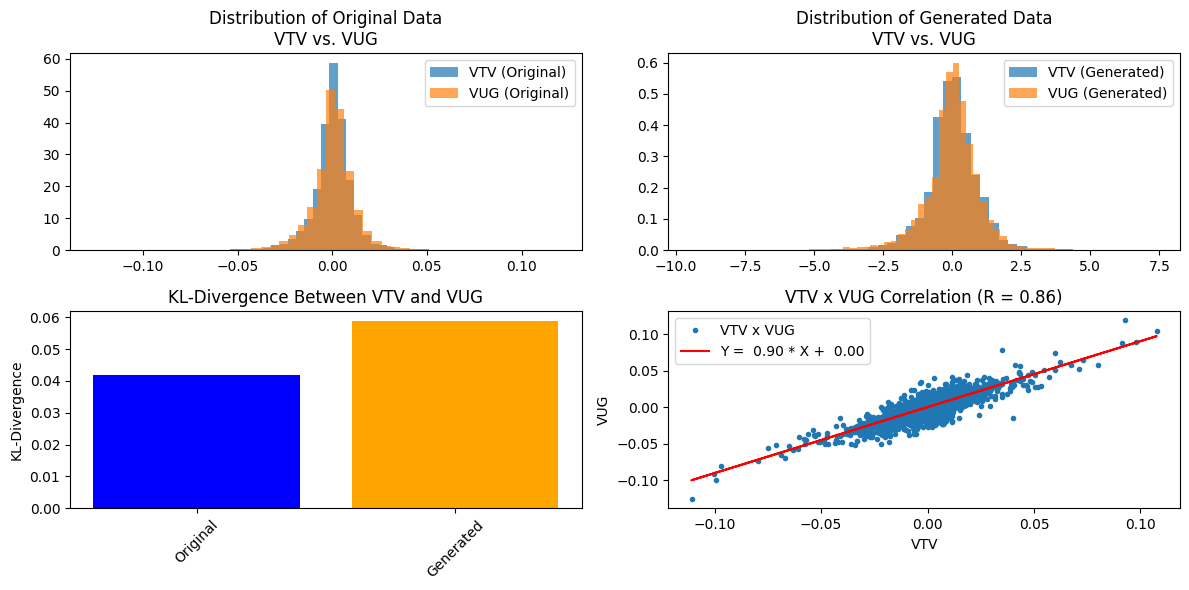

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VTV and MTUM : 0.09917044837031301
Generated ETF Pair's KL-Divergence between VTV and MTUM : 0.10590411419881943


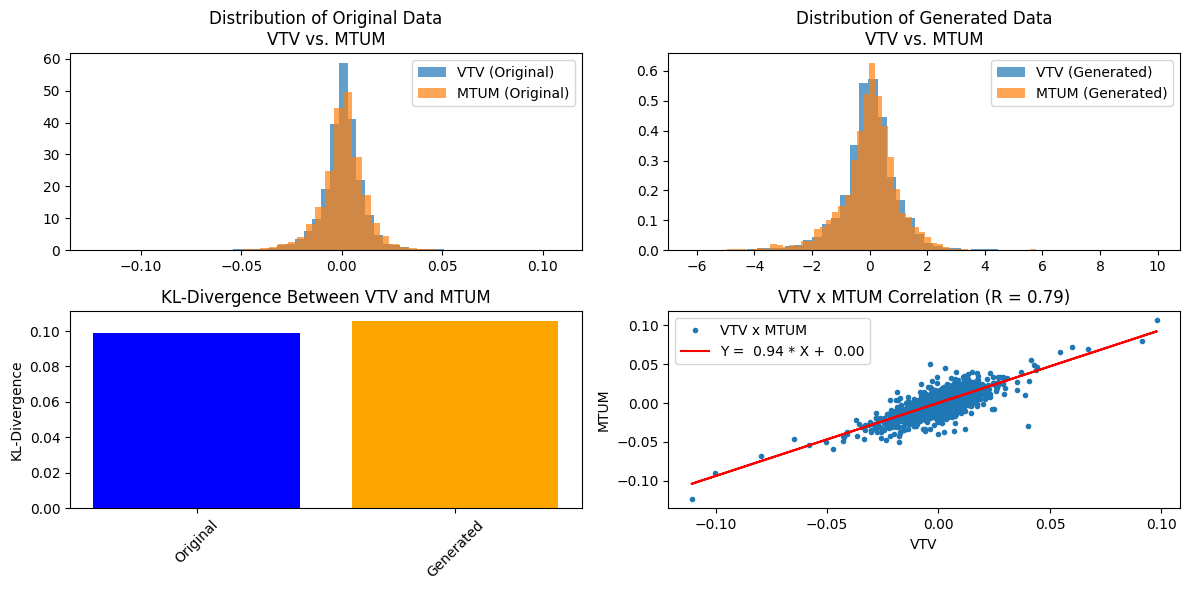

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VTV and QUAL : 0.0713055229141009
Generated ETF Pair's KL-Divergence between VTV and QUAL : 0.08254261748100687


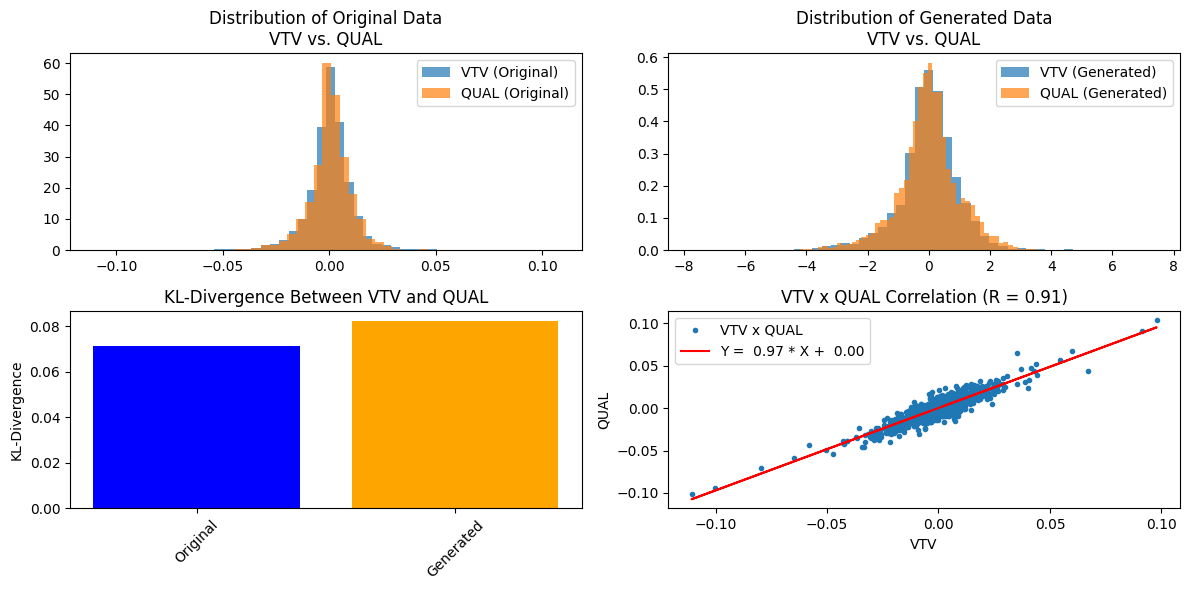

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VTV and VYMI : 0.15819181776867056
Generated ETF Pair's KL-Divergence between VTV and VYMI : 0.17267374206242575


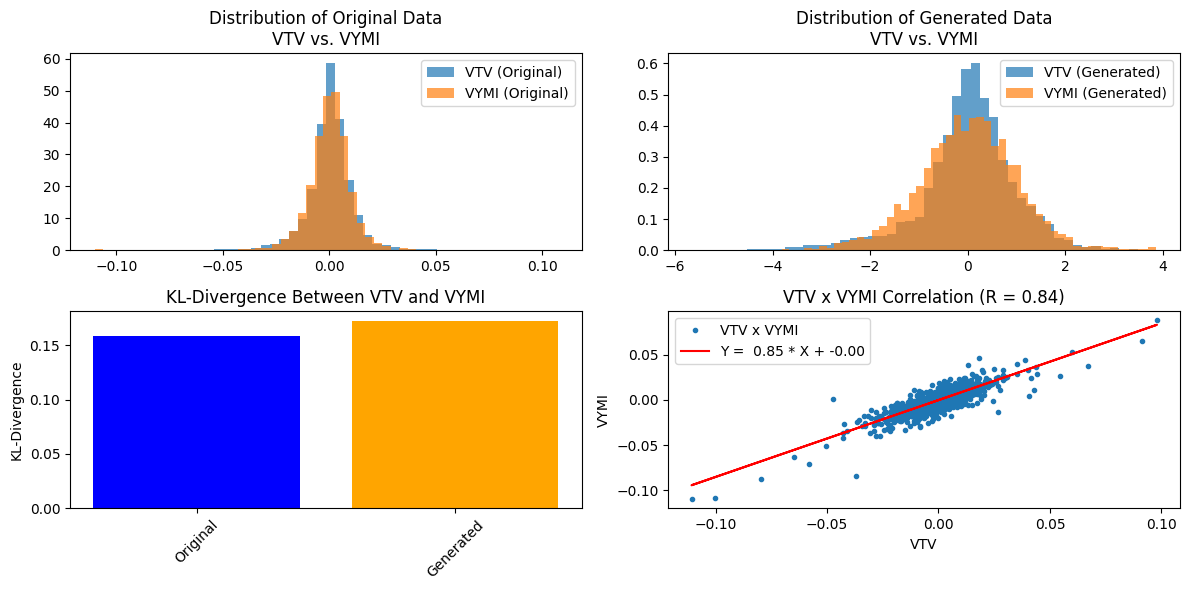

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VTV and USMV : 0.18408121294462046
Generated ETF Pair's KL-Divergence between VTV and USMV : 0.09004129142264213


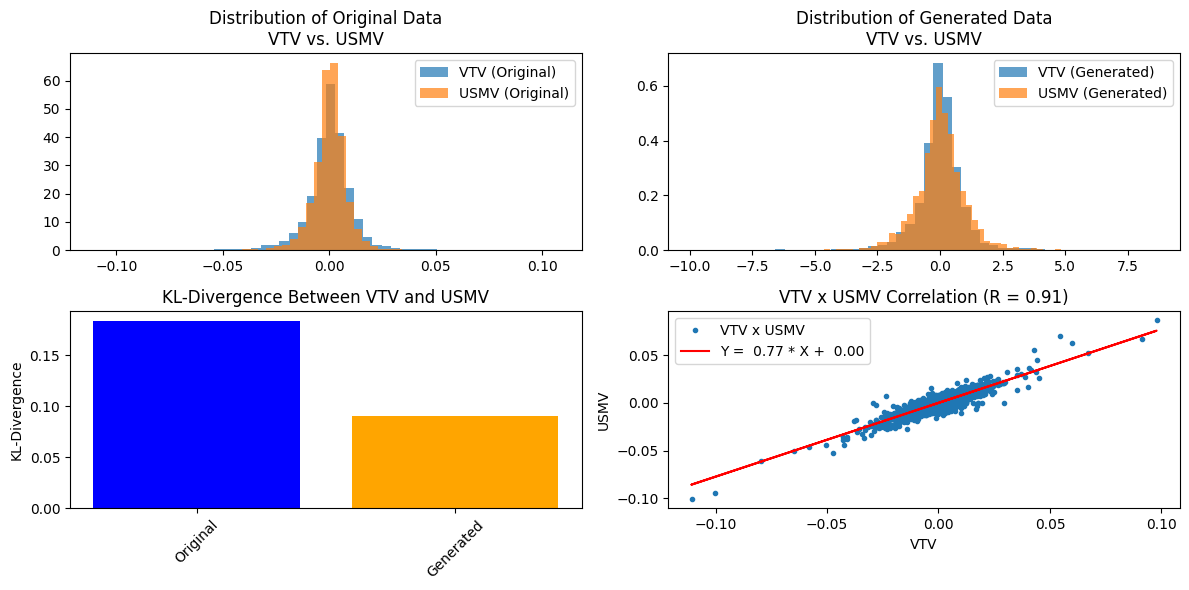

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VTV and KBE : 0.1361094713013301
Generated ETF Pair's KL-Divergence between VTV and KBE : 0.02535554989268046


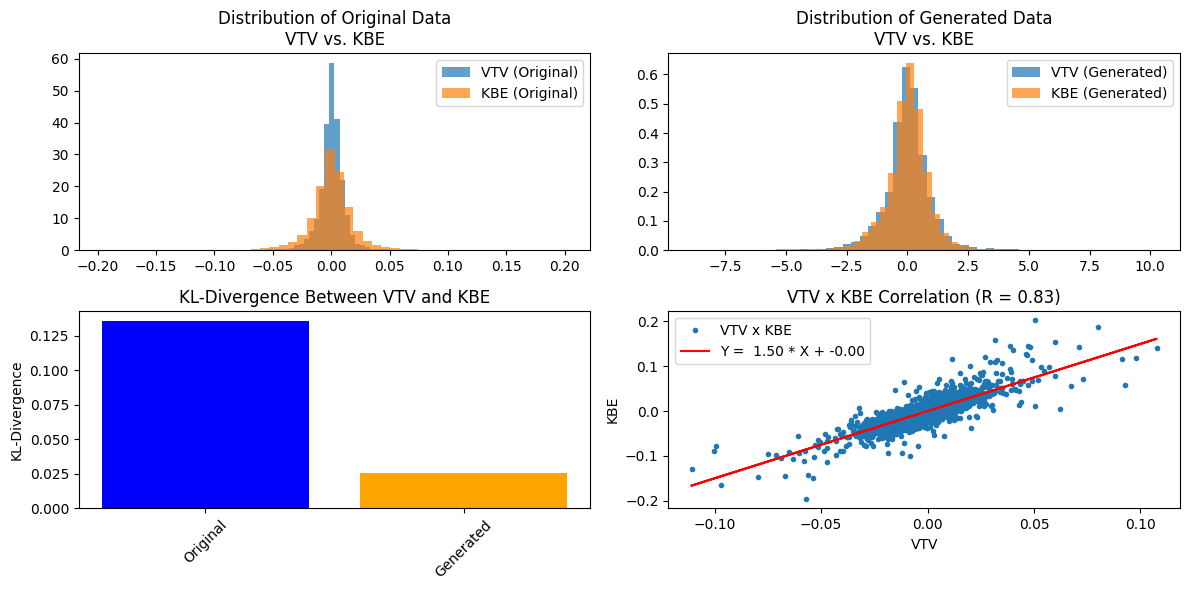

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VTV and IYK : 0.05510458131710706
Generated ETF Pair's KL-Divergence between VTV and IYK : 0.046024620235597266


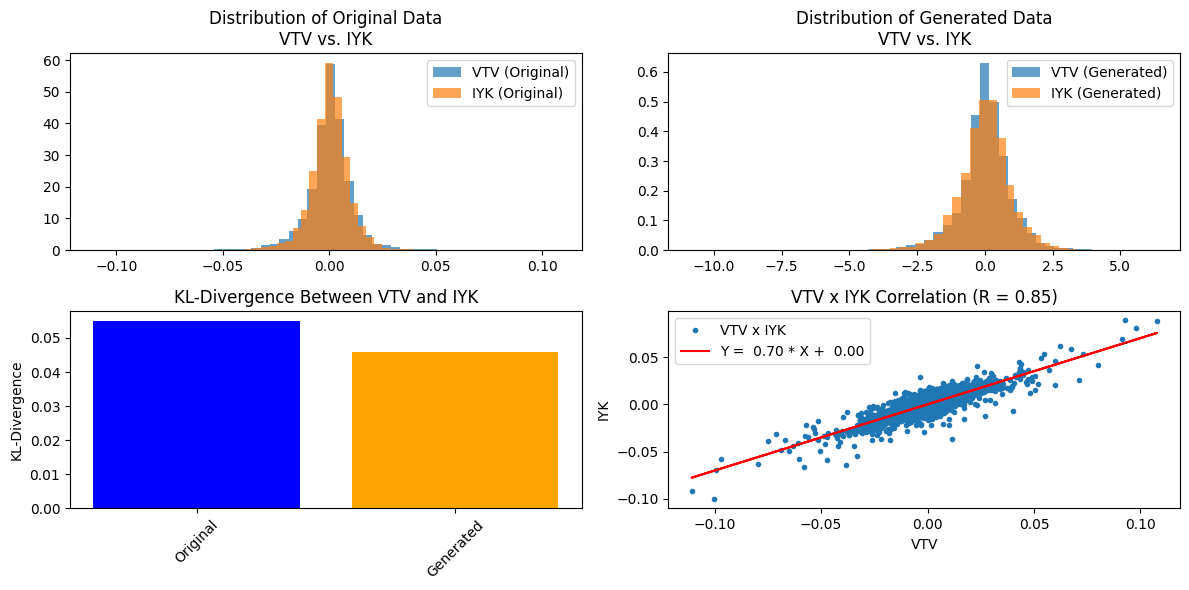

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VTV and IYC : 0.05701243760199389
Generated ETF Pair's KL-Divergence between VTV and IYC : 0.07449791604747867


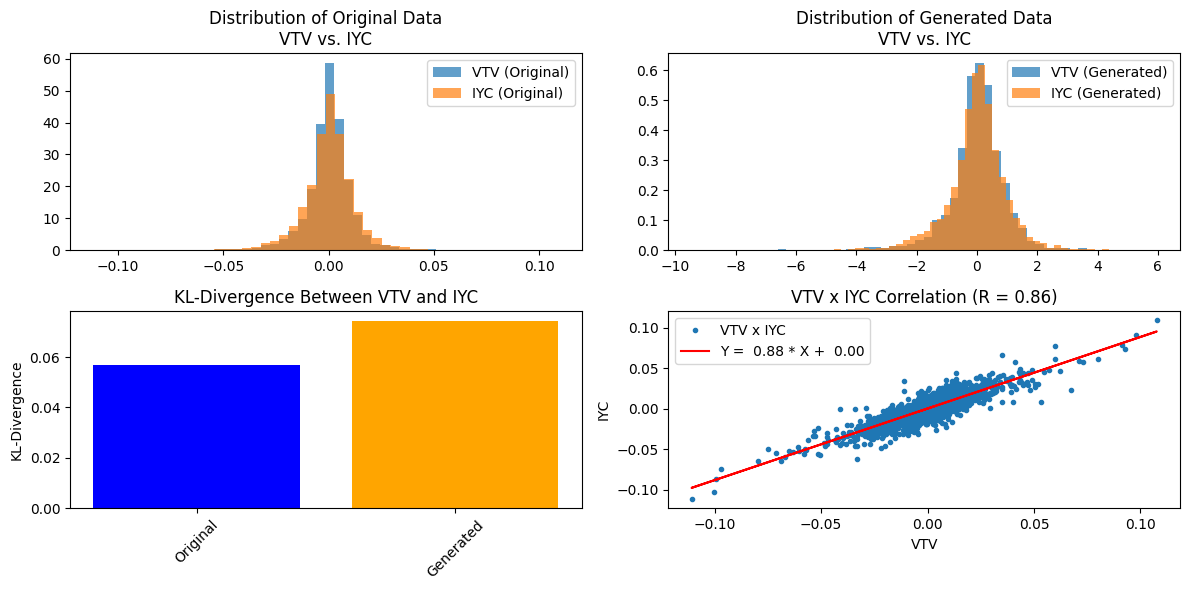

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VUG and MTUM : 0.04803816524568166
Generated ETF Pair's KL-Divergence between VUG and MTUM : 0.10158675230315338


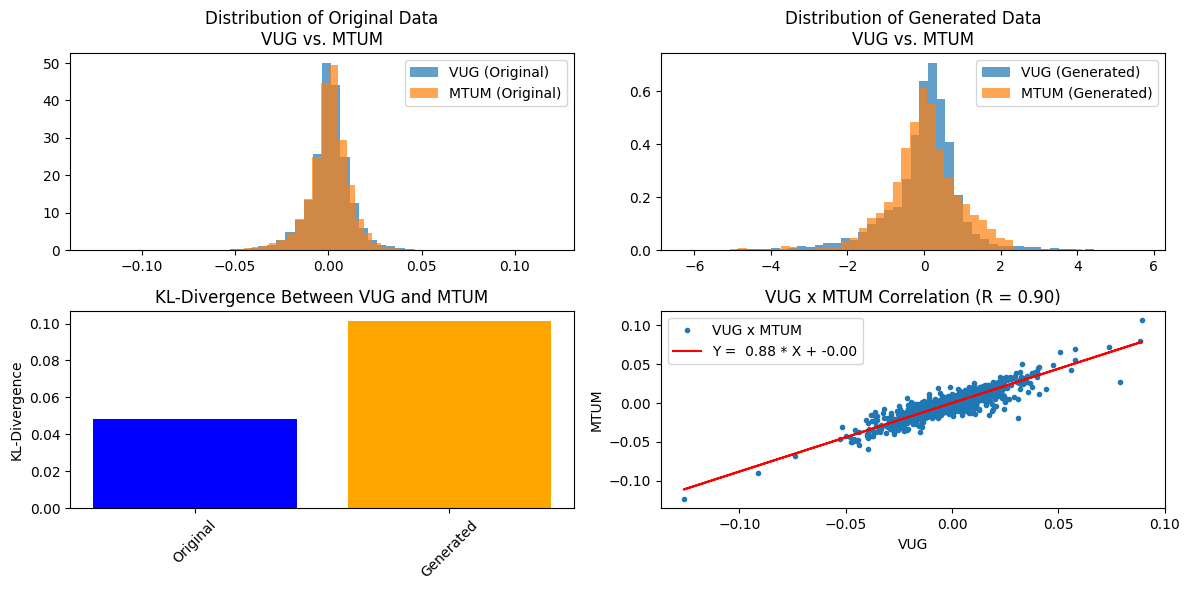

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VUG and QUAL : 0.05817223704607165
Generated ETF Pair's KL-Divergence between VUG and QUAL : 0.05235715560367617


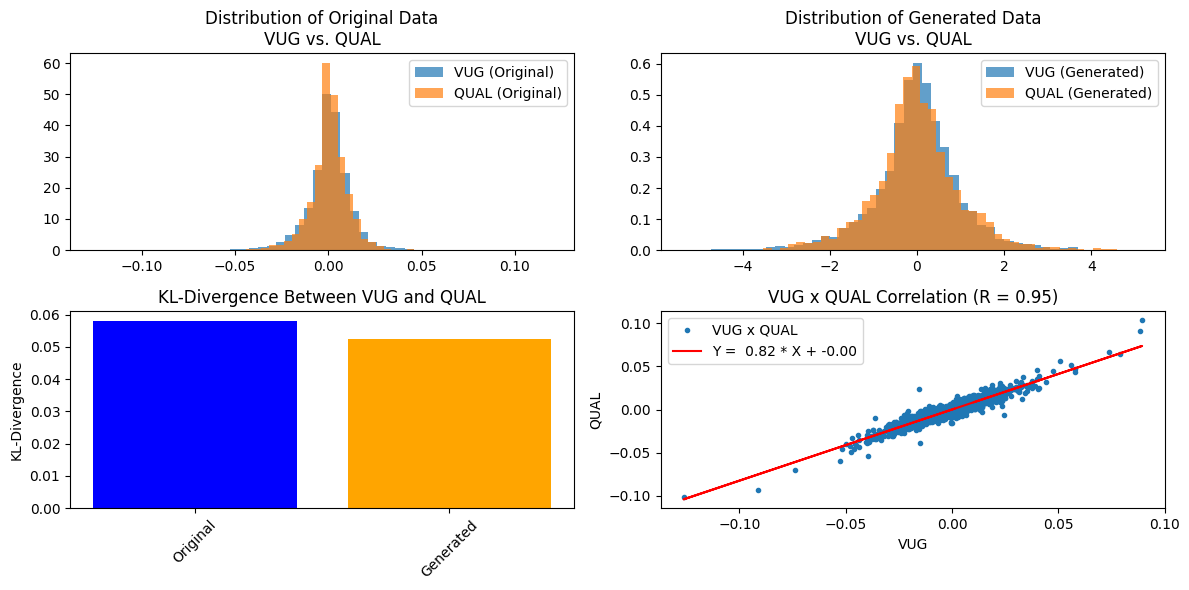

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VUG and VYMI : 0.13046083051226828
Generated ETF Pair's KL-Divergence between VUG and VYMI : 0.12084776027813436


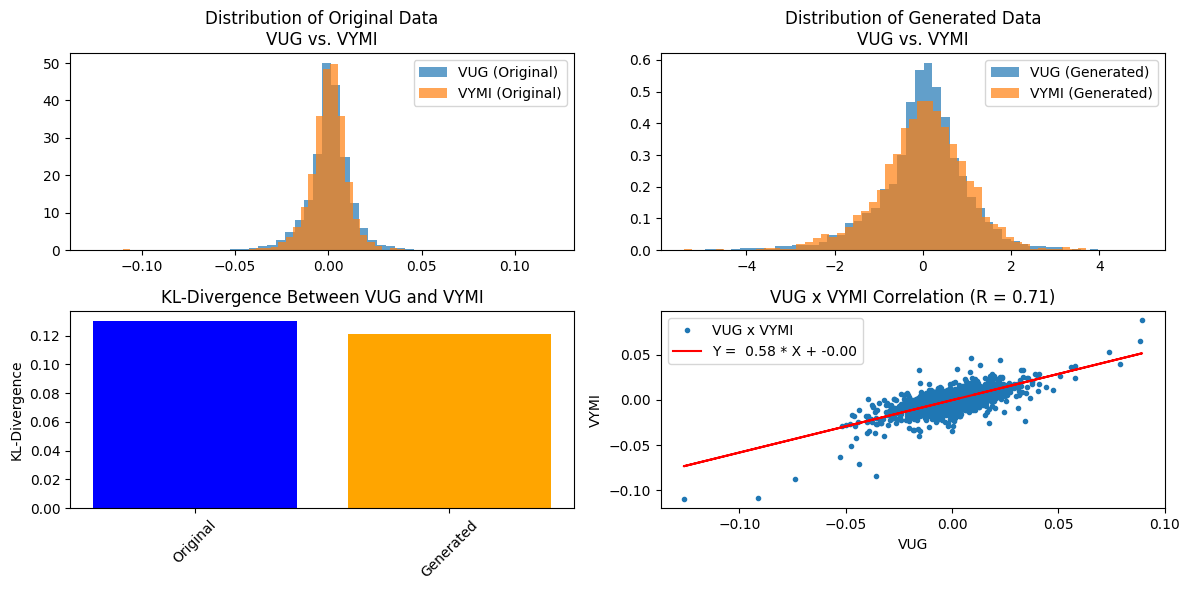

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VUG and USMV : 0.15809008849216116
Generated ETF Pair's KL-Divergence between VUG and USMV : 0.062303719066948524


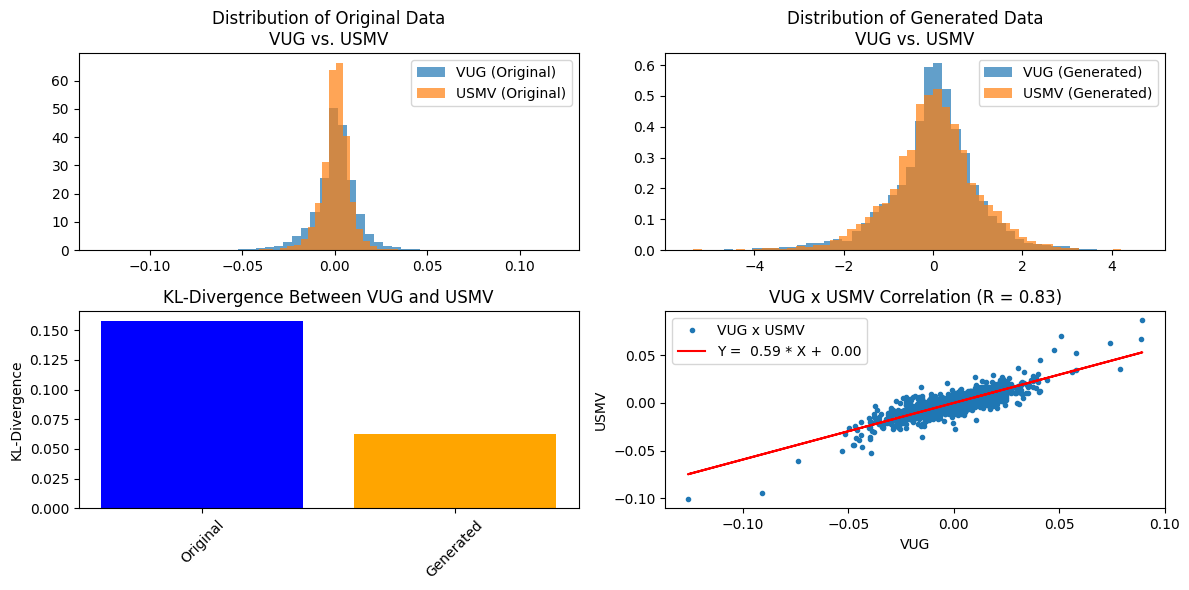

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VUG and KBE : 0.10609668583026553
Generated ETF Pair's KL-Divergence between VUG and KBE : 0.03467596313123827


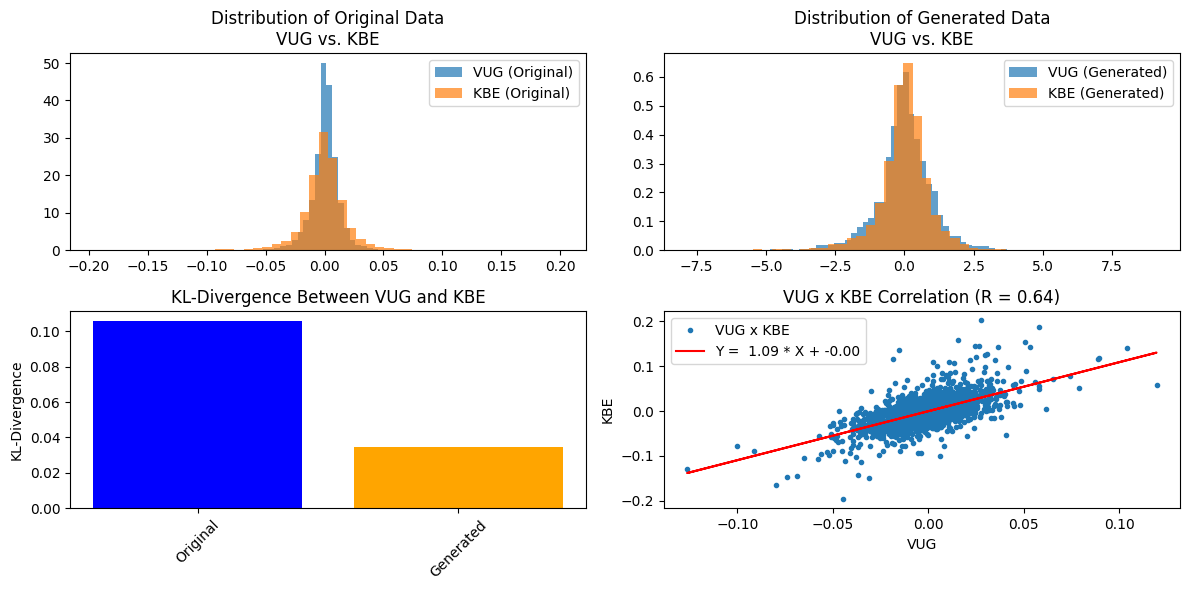

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VUG and IYK : 0.06169890677743752
Generated ETF Pair's KL-Divergence between VUG and IYK : 0.024920706730398114


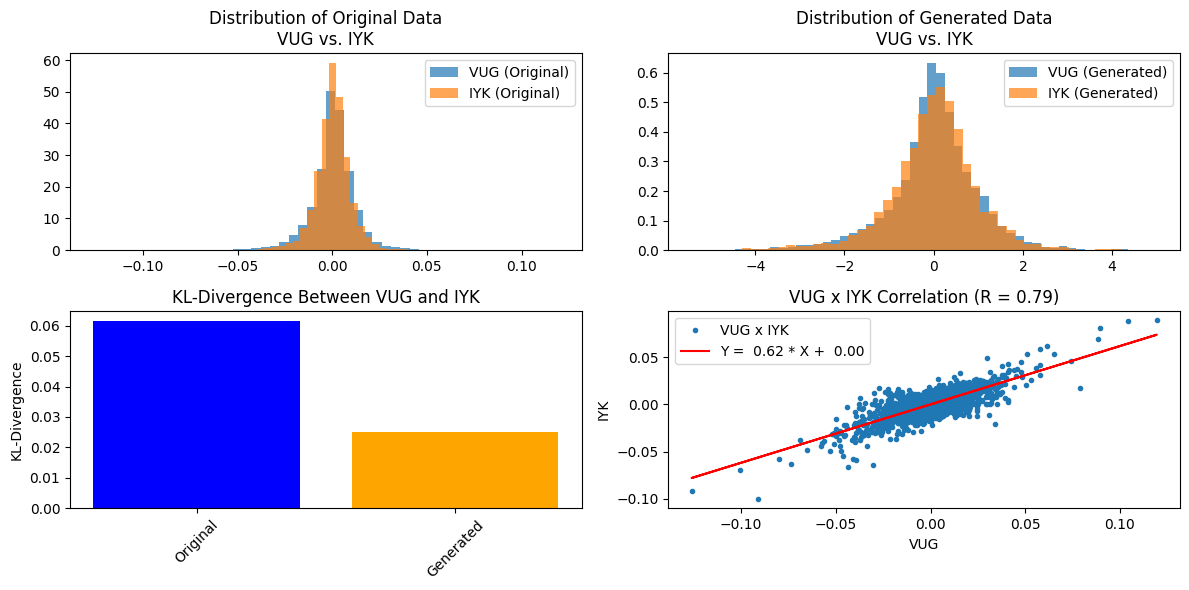

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VUG and IYC : 0.03492712687740755
Generated ETF Pair's KL-Divergence between VUG and IYC : 0.011690115031830204


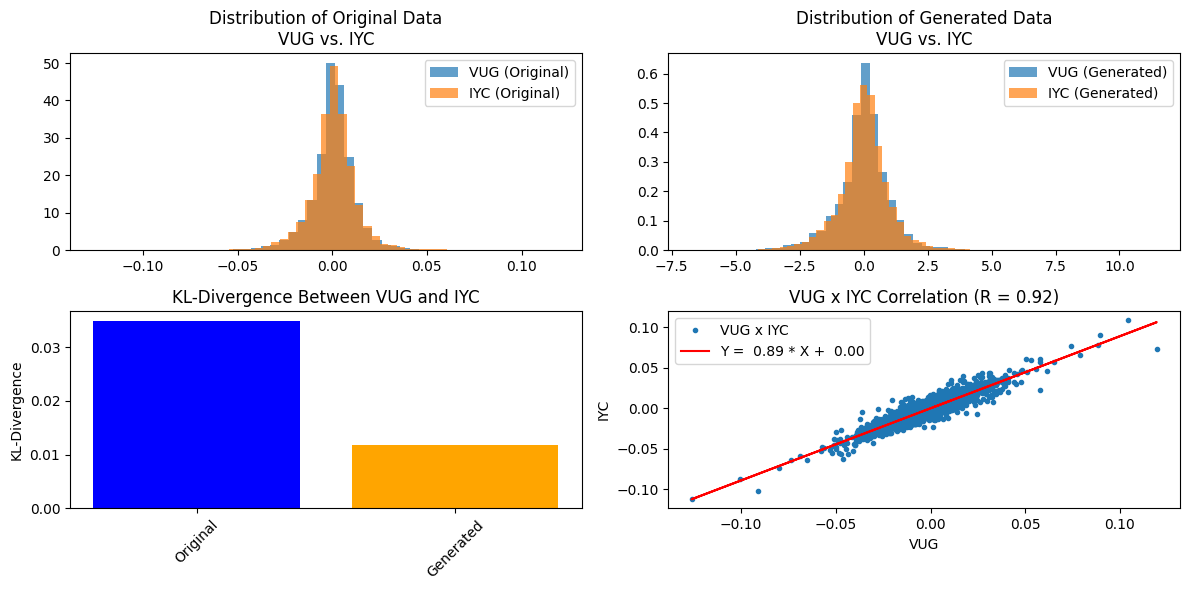

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between MTUM and QUAL : 0.06506450221941547
Generated ETF Pair's KL-Divergence between MTUM and QUAL : 0.11659832187725527


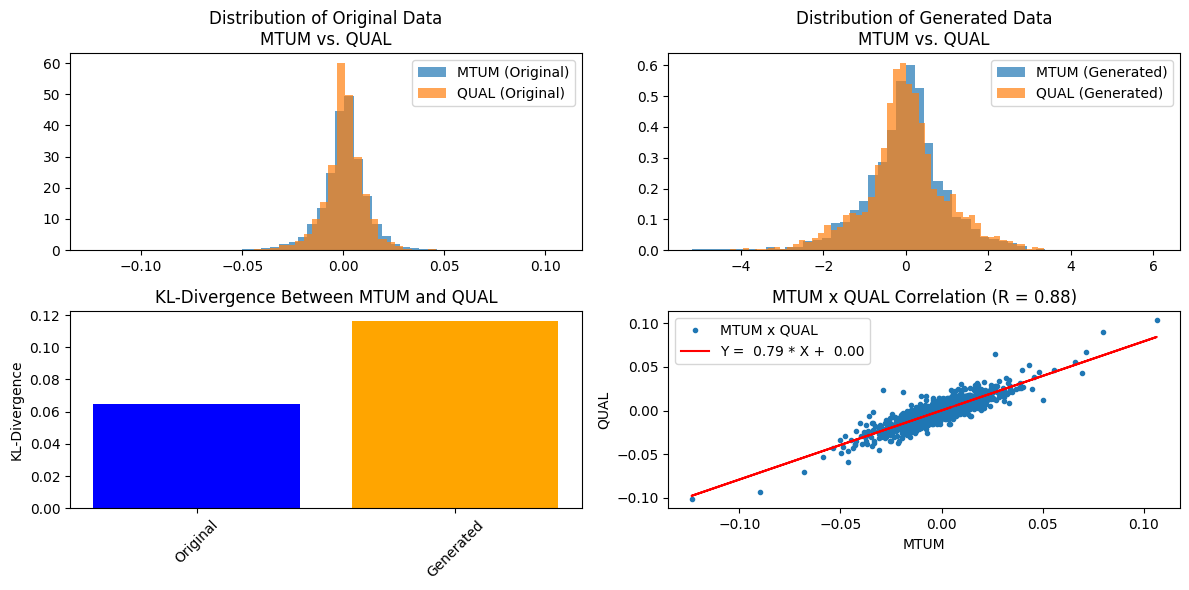

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between MTUM and VYMI : 0.11778460081898398
Generated ETF Pair's KL-Divergence between MTUM and VYMI : 0.06318636655760063


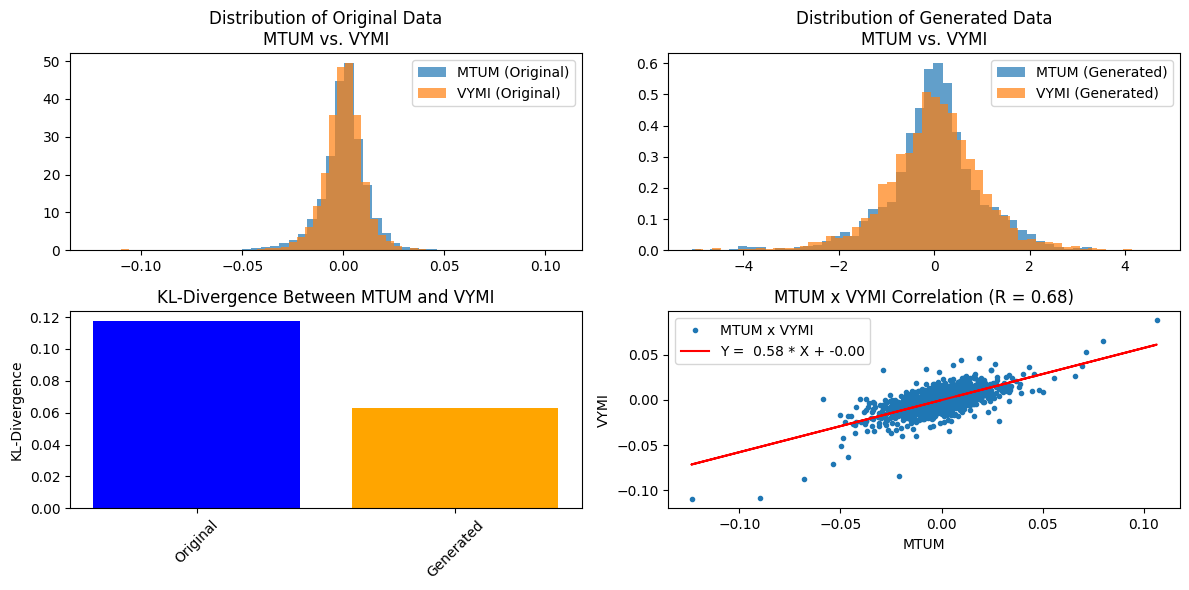

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between MTUM and USMV : 0.1794417036425847
Generated ETF Pair's KL-Divergence between MTUM and USMV : 0.07231924656279322


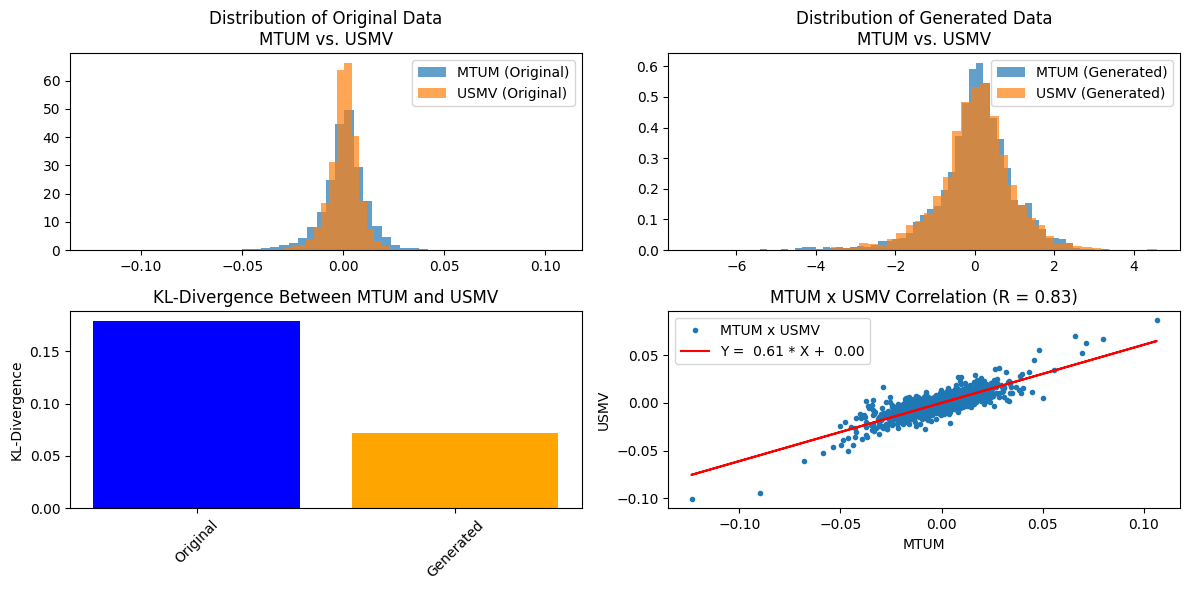

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between MTUM and KBE : 0.11268920914010544
Generated ETF Pair's KL-Divergence between MTUM and KBE : 0.06113612934982639


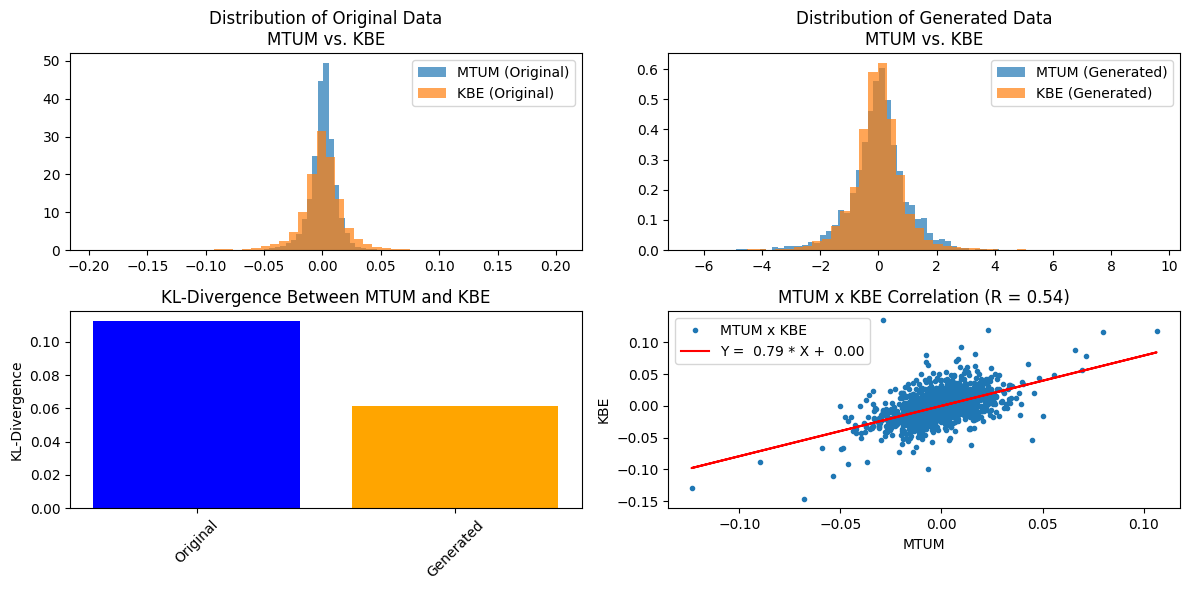

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between MTUM and IYK : 0.06218273231846699
Generated ETF Pair's KL-Divergence between MTUM and IYK : 0.03175325050206727


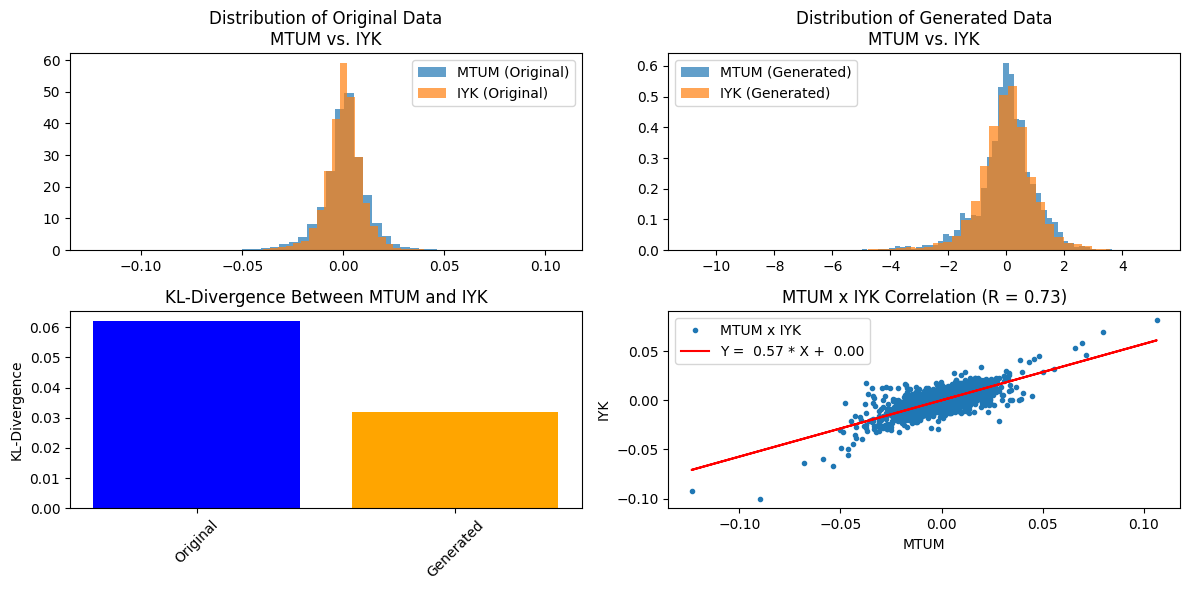

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between MTUM and IYC : 0.028508535939870426
Generated ETF Pair's KL-Divergence between MTUM and IYC : 0.0470020452505016


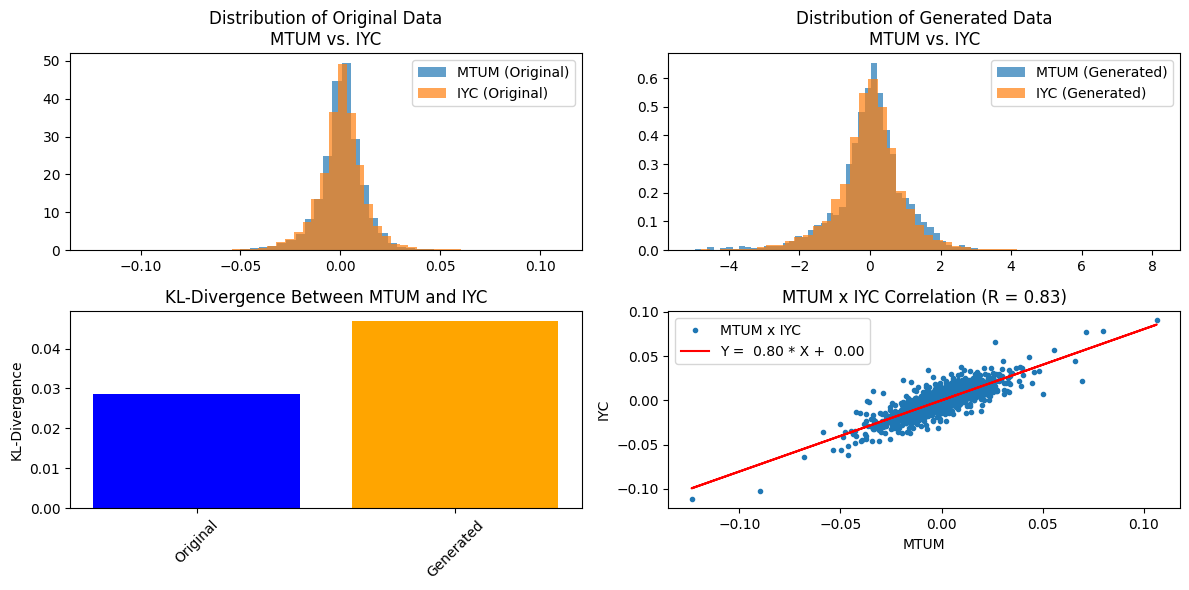

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between QUAL and VYMI : 0.08119172737704405
Generated ETF Pair's KL-Divergence between QUAL and VYMI : 0.10536383087551406


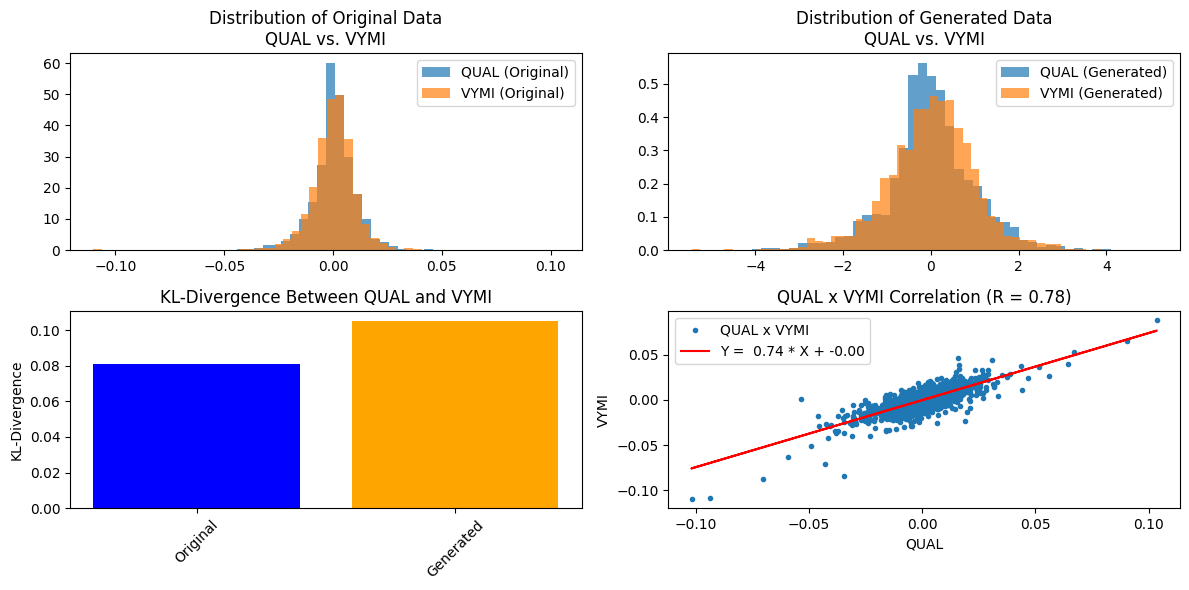

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between QUAL and USMV : 0.08144719401900094
Generated ETF Pair's KL-Divergence between QUAL and USMV : 0.047122531648053766


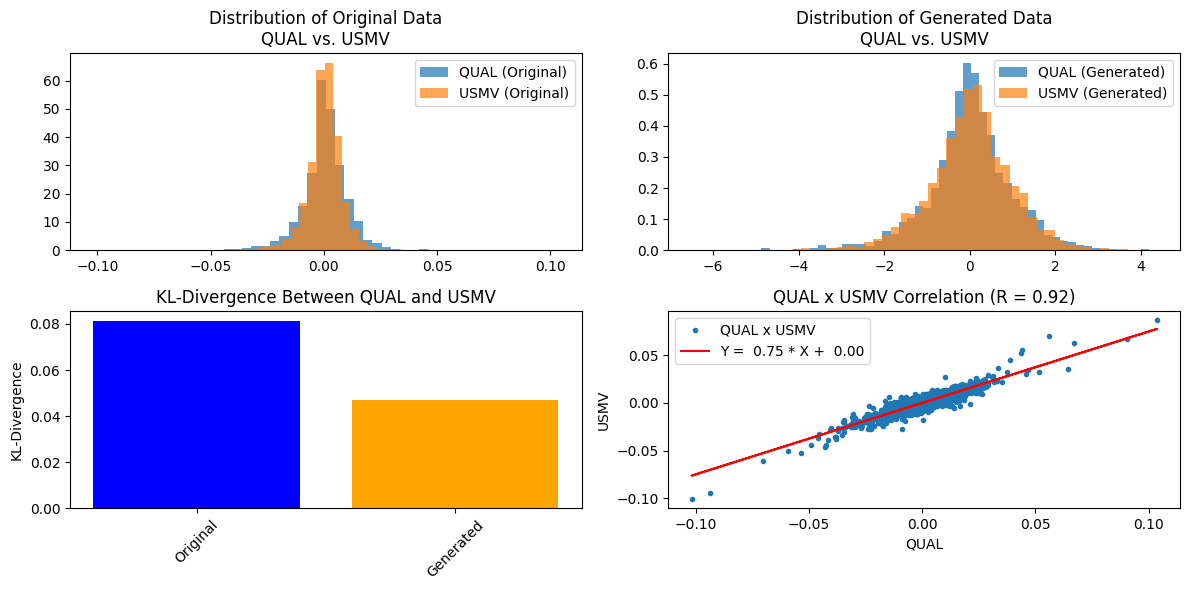

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between QUAL and KBE : 0.16611726621501177
Generated ETF Pair's KL-Divergence between QUAL and KBE : 0.06862854895300613


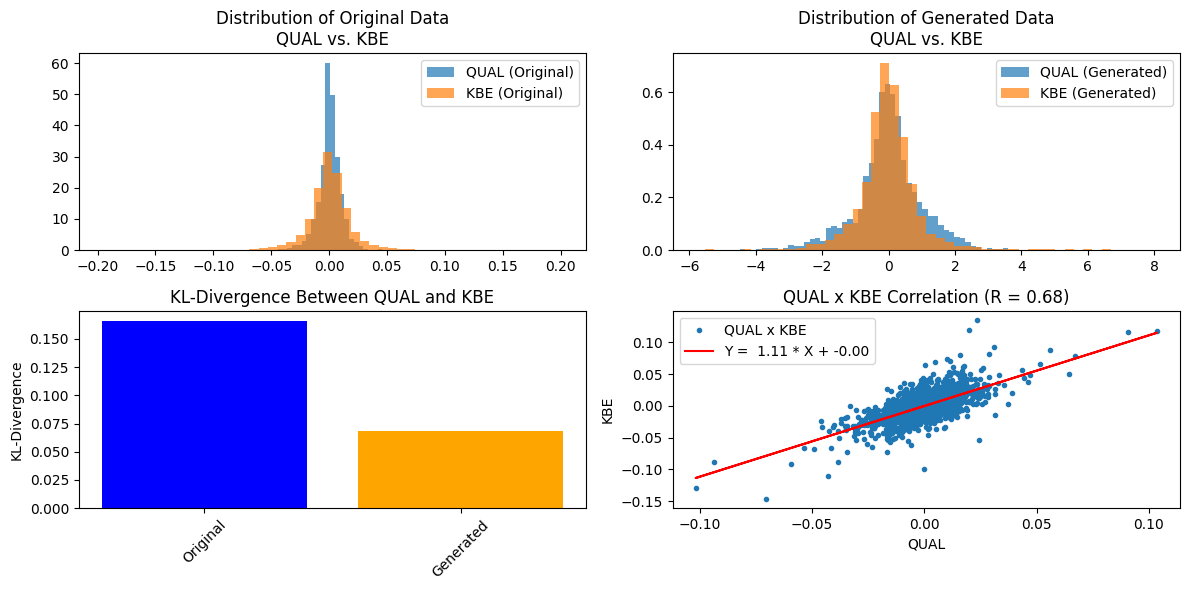

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between QUAL and IYK : 0.03494087915798816
Generated ETF Pair's KL-Divergence between QUAL and IYK : 0.026804203673360477


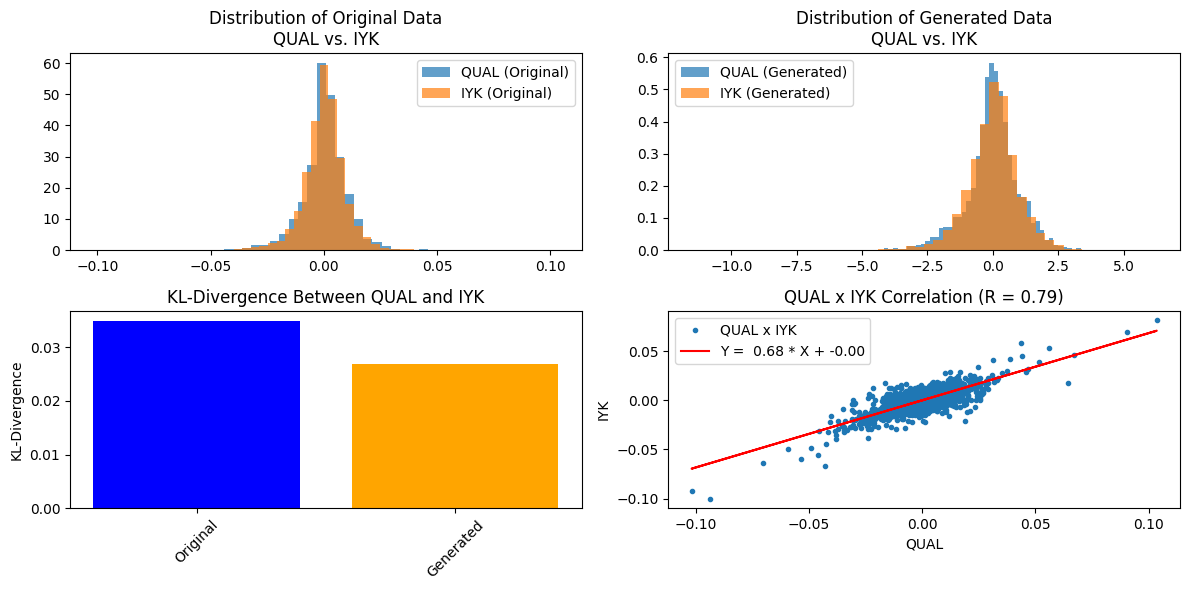

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between QUAL and IYC : 0.06126942985688365
Generated ETF Pair's KL-Divergence between QUAL and IYC : 0.02918040353870098


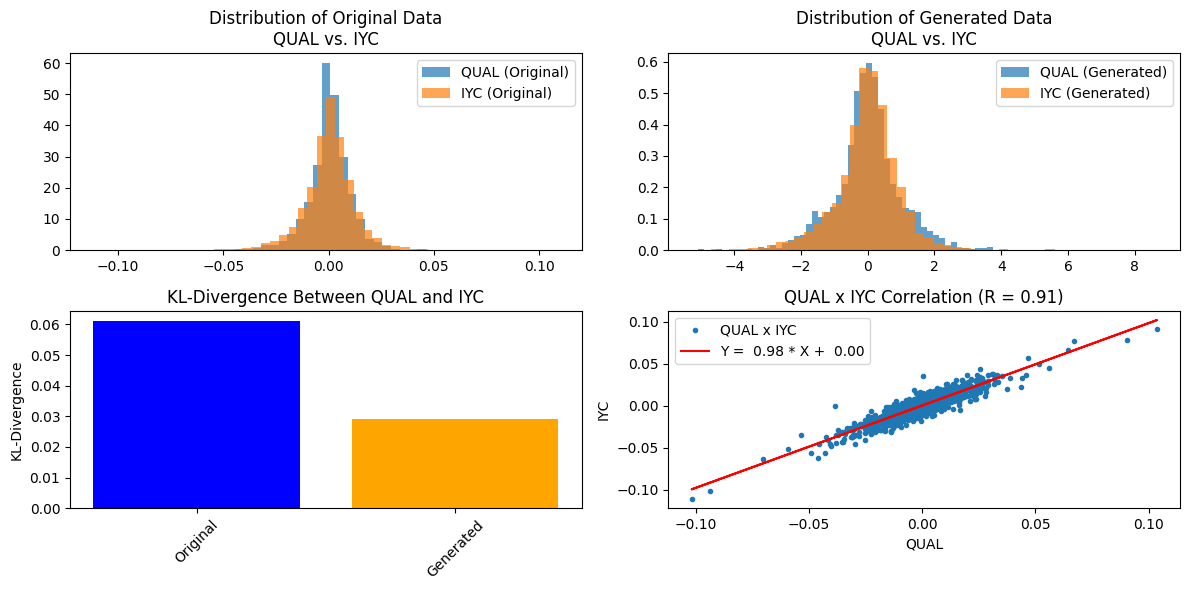

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VYMI and USMV : 0.16967300567102717
Generated ETF Pair's KL-Divergence between VYMI and USMV : 0.03838370213883063


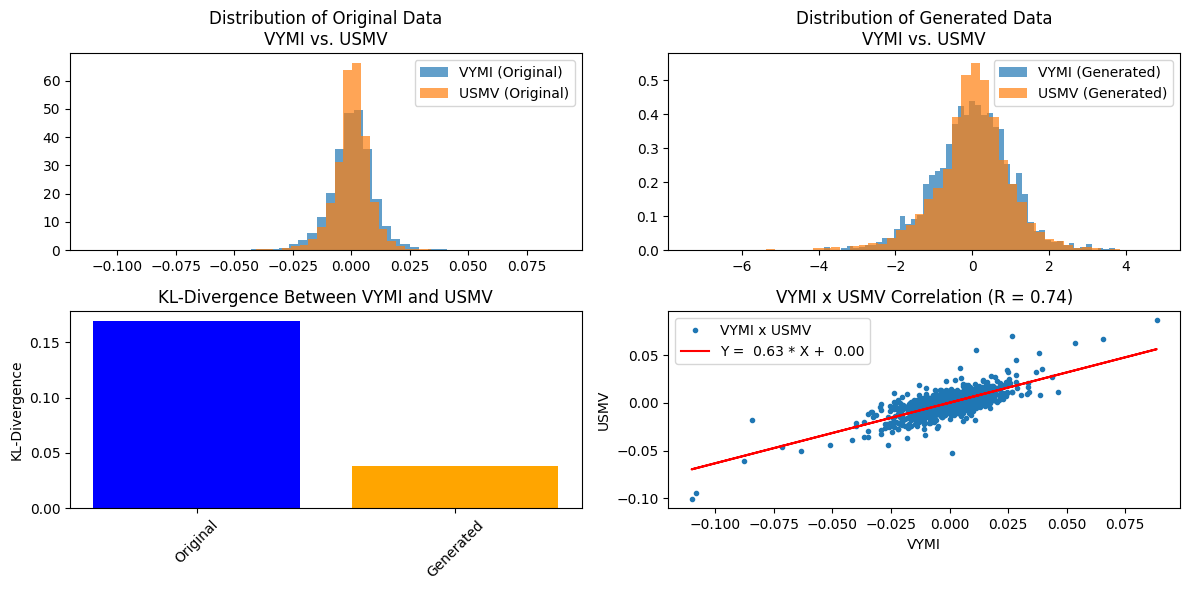

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VYMI and KBE : 0.16179186819617306
Generated ETF Pair's KL-Divergence between VYMI and KBE : 0.07417578009291279


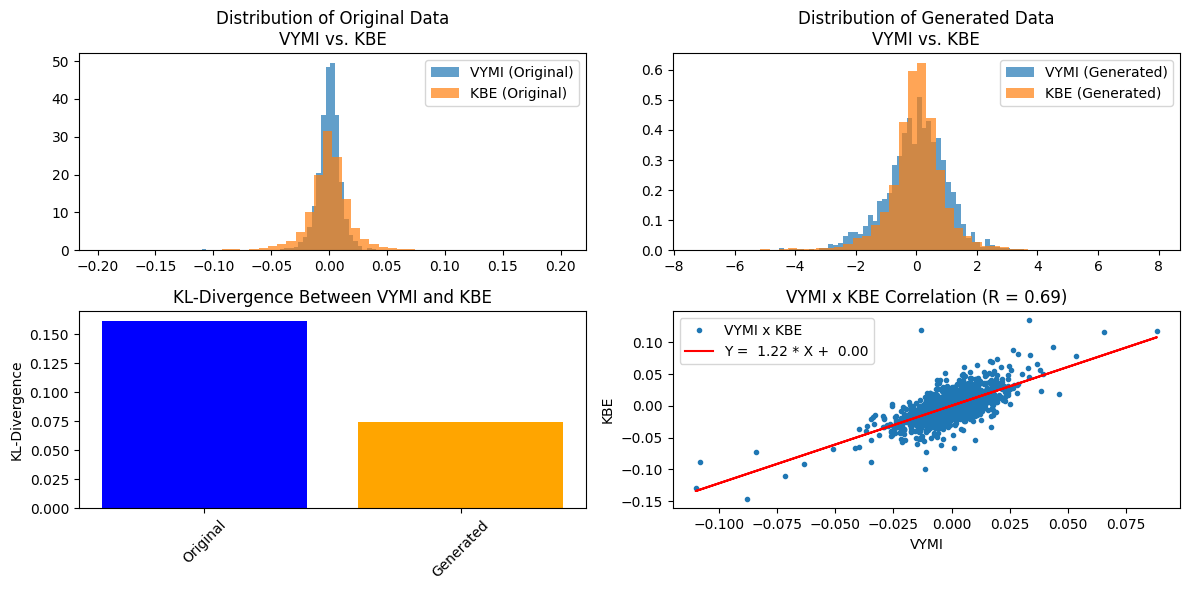

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VYMI and IYK : 0.06678276462386631
Generated ETF Pair's KL-Divergence between VYMI and IYK : 0.031060126808881375


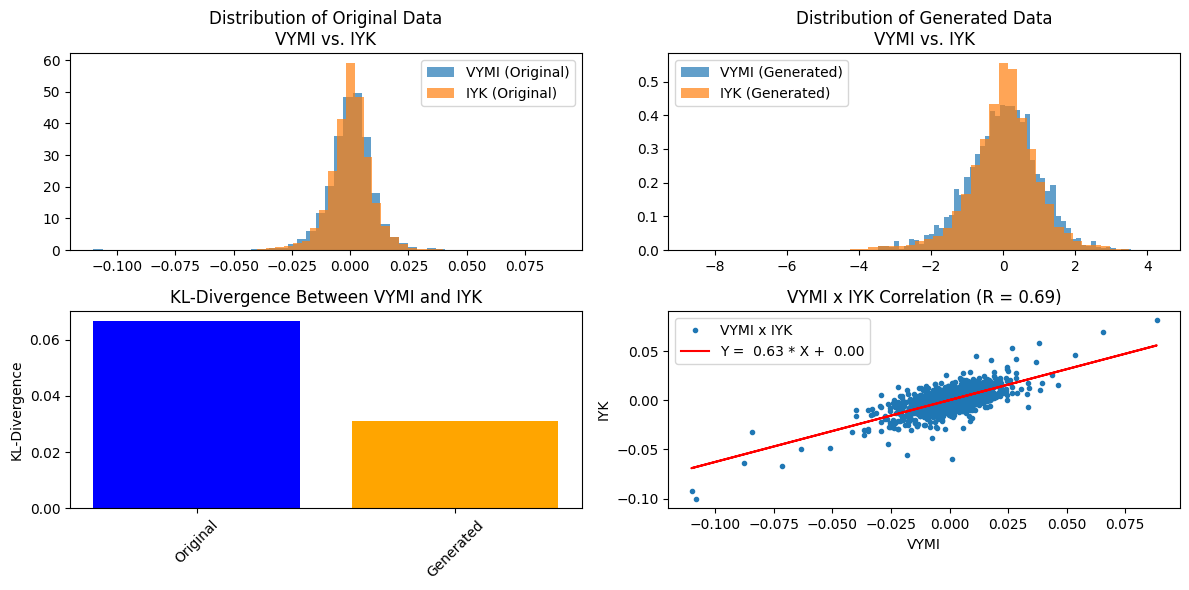

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between VYMI and IYC : 0.06722120222904356
Generated ETF Pair's KL-Divergence between VYMI and IYC : 0.0315960875466717


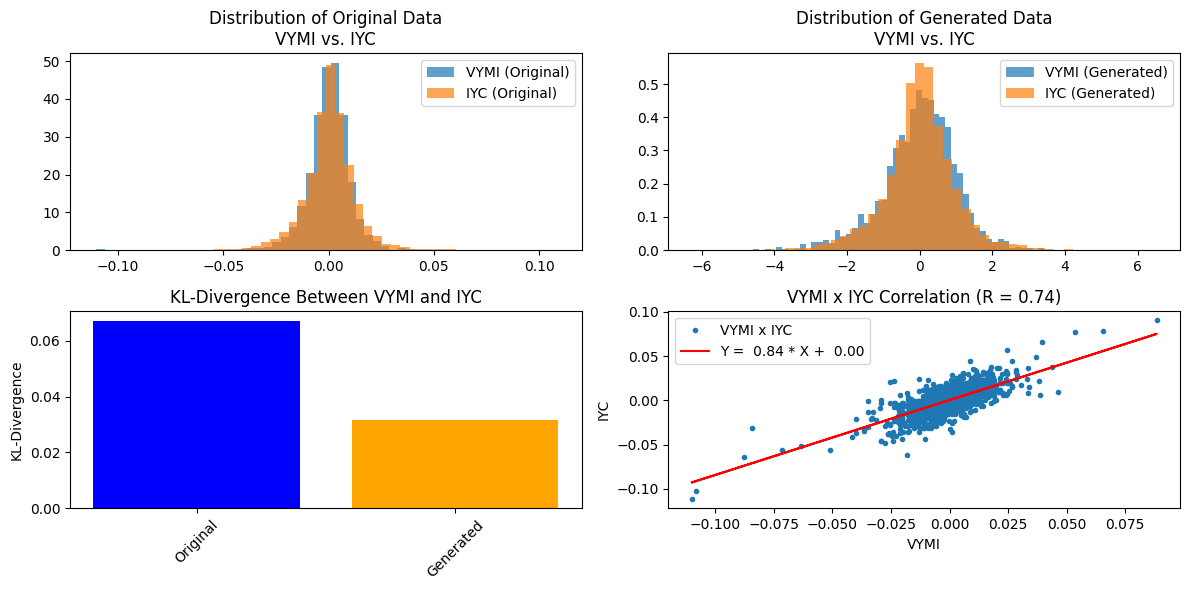

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between USMV and KBE : 0.28654388020367905
Generated ETF Pair's KL-Divergence between USMV and KBE : 0.08148503012239887


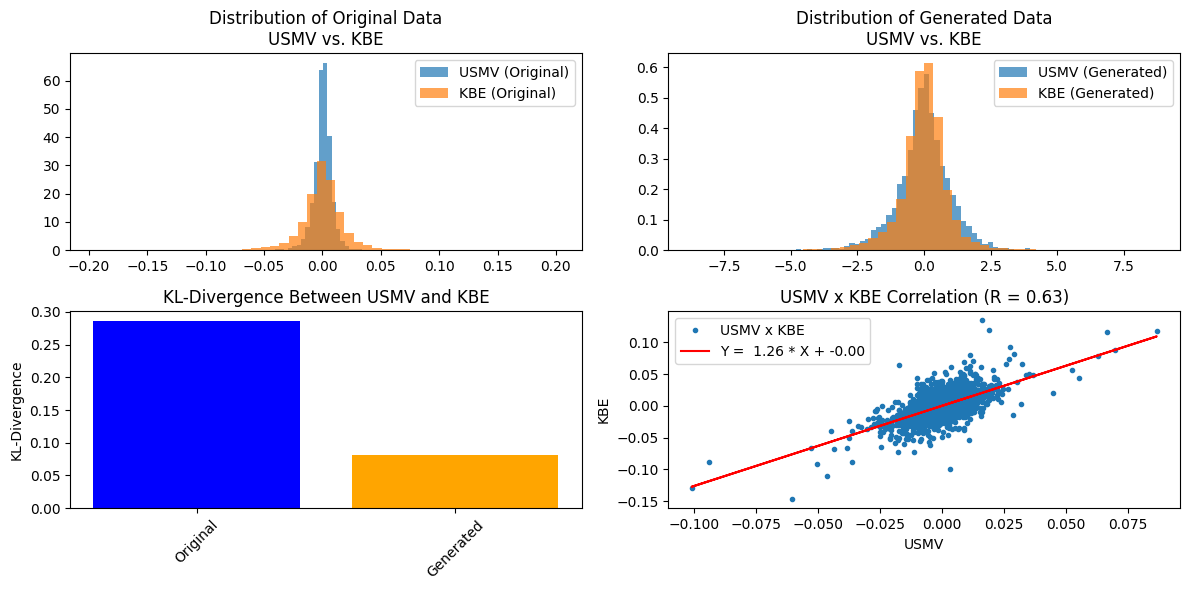

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between USMV and IYK : 0.047005508870239784
Generated ETF Pair's KL-Divergence between USMV and IYK : 0.026429788844767974


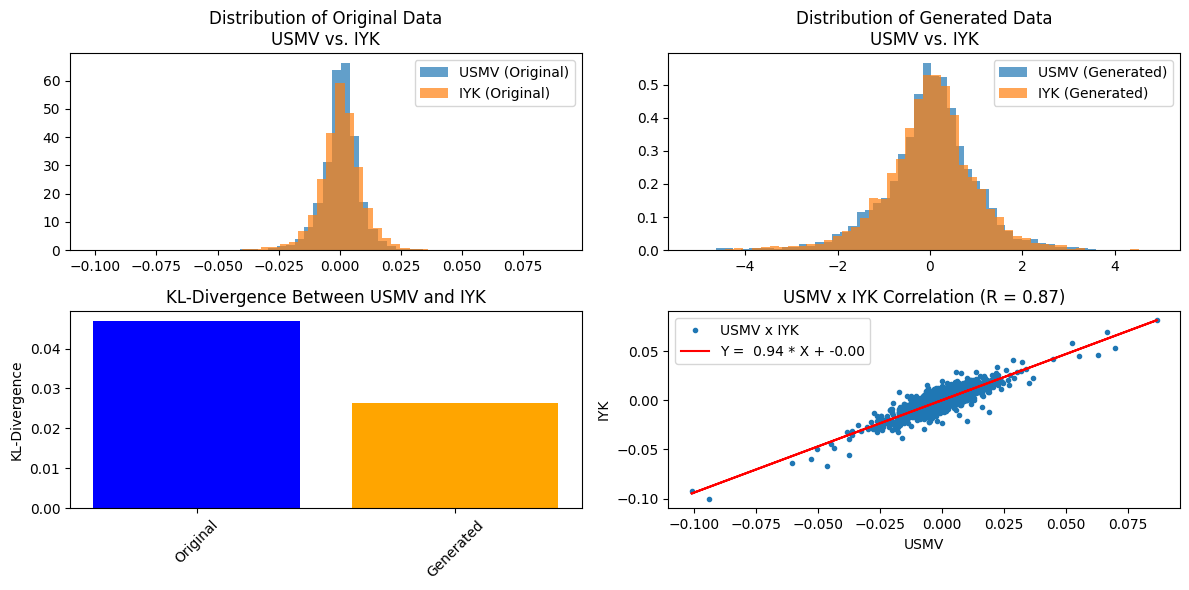

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between USMV and IYC : 0.11939628103568434
Generated ETF Pair's KL-Divergence between USMV and IYC : 0.029495868622074803


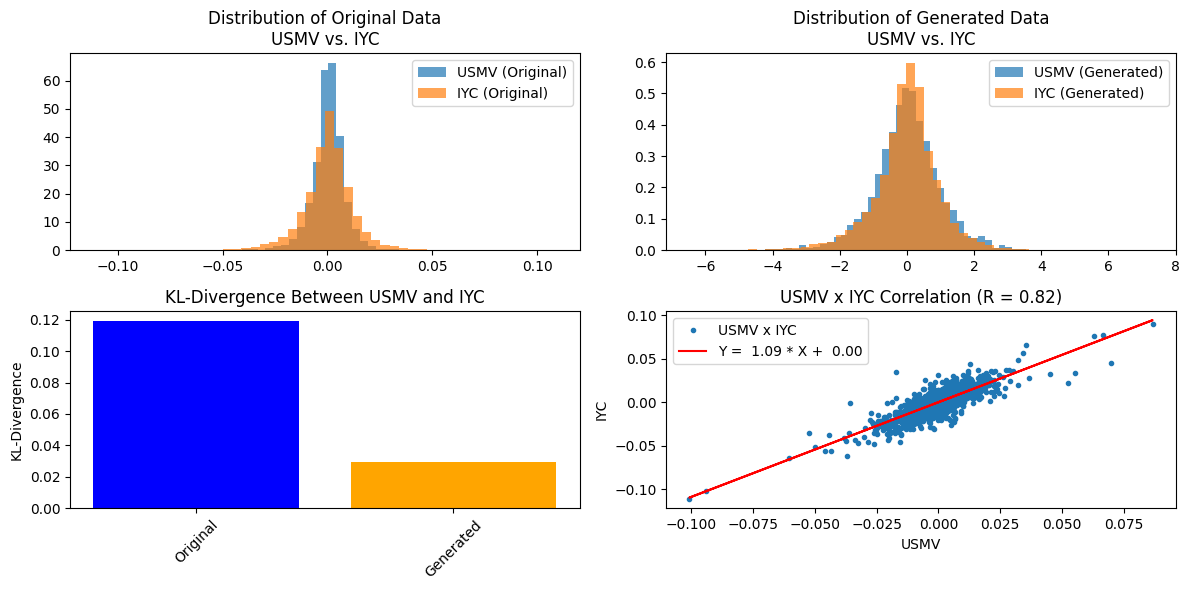

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between KBE and IYK : 0.4124816139355421
Generated ETF Pair's KL-Divergence between KBE and IYK : 0.07752169560138564


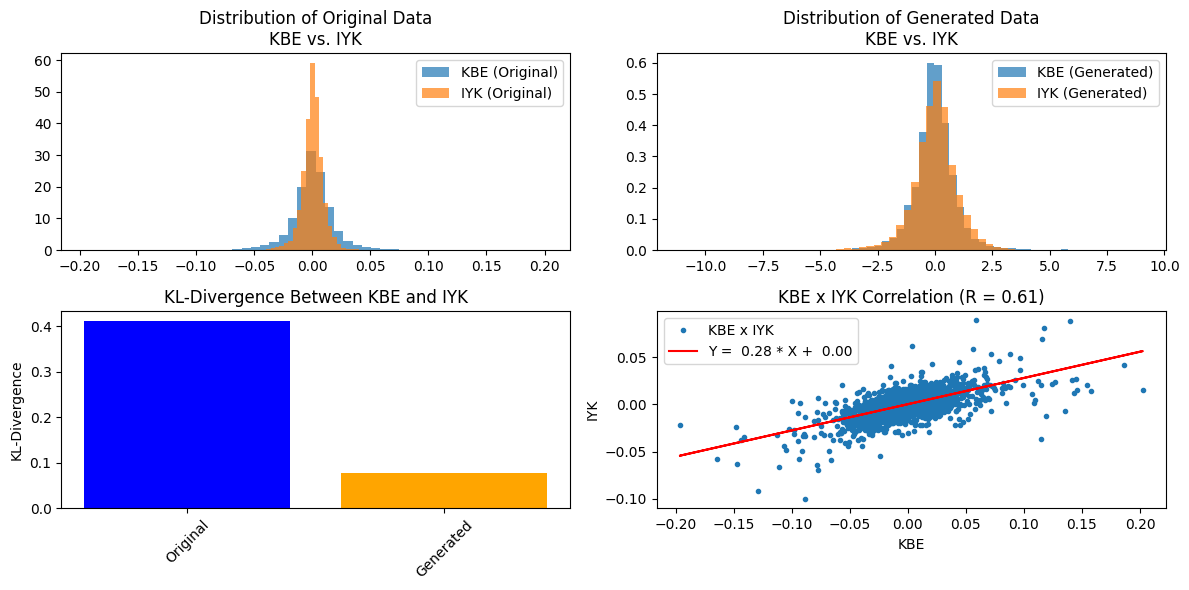

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between KBE and IYC : 0.2549422512618244
Generated ETF Pair's KL-Divergence between KBE and IYC : 0.0292436122064089


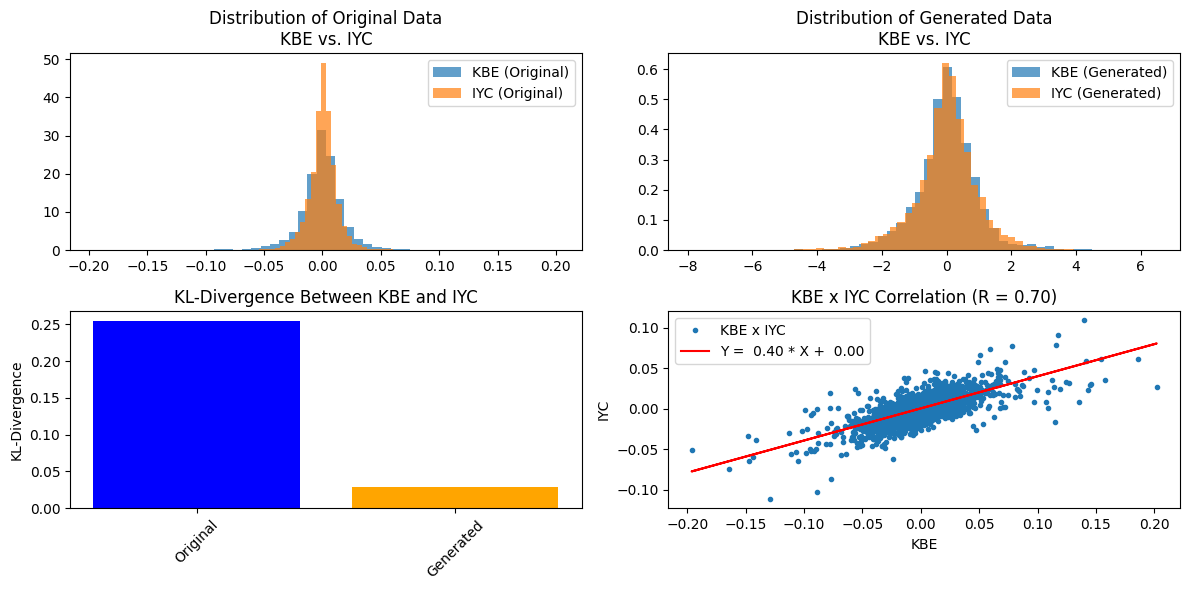

/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.10/dist-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Original ETF Pair's KL-Divergence between IYK and IYC : 0.06011860791274075
Generated ETF Pair's KL-Divergence between IYK and IYC : 0.01931704439154621


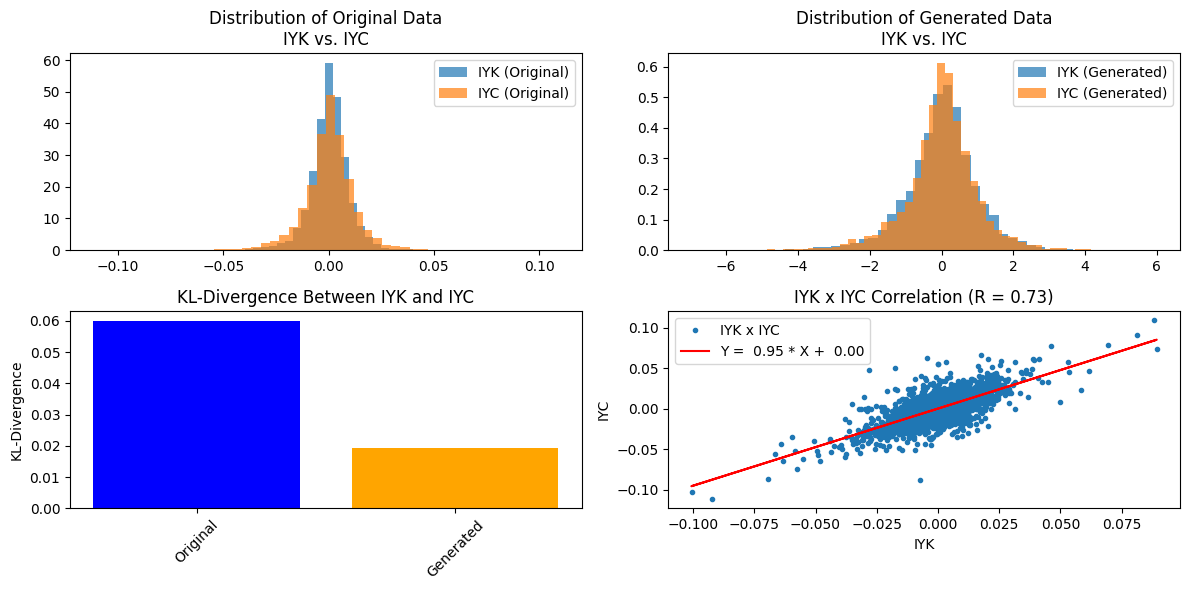

[[['IWM', 'SPY'], 0.10485143427015396], [['IWM', 'VTV'], 0.1182067712280523], [['IWM', 'VUG'], 0.08645892928916452], [['IWM', 'MTUM'], 0.1364647719204022], [['IWM', 'QUAL'], 0.18520076418401113], [['IWM', 'VYMI'], 0.31618727754297404], [['IWM', 'USMV'], 0.5326869320071261], [['IWM', 'KBE'], 0.029099916090092645], [['IWM', 'IYK'], 0.20714479803943828], [['IWM', 'IYC'], 0.09150164551976726], [['SPY', 'VTV'], 0.01868743862950714], [['SPY', 'VUG'], 0.020760487500874336], [['SPY', 'MTUM'], 0.04790132436036458], [['SPY', 'QUAL'], 0.05942971369046535], [['SPY', 'VYMI'], 0.09350779944885718], [['SPY', 'USMV'], 0.15891644458392132], [['SPY', 'KBE'], 0.1167853137127603], [['SPY', 'IYK'], 0.04256555372442425], [['SPY', 'IYC'], 0.03014735779675616], [['VTV', 'VUG'], 0.04182785932353723], [['VTV', 'MTUM'], 0.09917044837031301], [['VTV', 'QUAL'], 0.0713055229141009], [['VTV', 'VYMI'], 0.15819181776867056], [['VTV', 'USMV'], 0.18408121294462046], [['VTV', 'KBE'], 0.1361094713013301], [['VTV', 'IYK'],

In [ ]:
if __name__ == "__main__":

    KLD_list = []

    generateETFReturns()

    KLD_list.sort(key = lambda k : k[1]) # KL-D 값 기준 오름차순 정렬

    print(KLD_list) # 리스트 출력해서 페어트레이딩할 종목 쌍을 결정하는 데 참고

    # KLD값 낮은 순으로, 상위 5개의 ETF 조합 추출
    top_5_pairs = KLD_list[:5]

    # 중복 없이 종목명을 추출하여 portfolio에 담기
    portfolio = list(set([symbol for pair in top_5_pairs for symbol in pair[0]]))

    print(portfolio)

# V. 페어 트레이딩 포트폴리오 최적화(241119 회의내용 복습) -> v3 수정

    두 개의 상호관련성이 높은 주식을 쌍으로 선택하여, 둘 간의 가격차이를 이용해 수익을 추구하는 투자전략.
    일반적으로 두 주식의 가격 차이가 정상분포를 따르는 것으로 가정하며, 상대적으로 가격이 높은 종목을 공매도(short)하고, 가격이 낮은 종목을 매수하는 방식.

- 장점 : 시장 전반의 하락에도 수익추구가 가능해짐. 리스크 분산가능. 포트폴리오 회전율이 높음. 거래 신호가 명확함.

- 단점 : 특정 시황이나 업종 추세에 크게 영향을 받음.

<br>

- 가정 : 타겟 ETF로 페어트레이딩이 가능한 총 조합 55개 중 KL-D값 작은 순으로 상위 5쌍을 추출함.

-> 이 종목들을 중복 없이 뽑아서 포트폴리오 짰다고 가정하고, 포트폴리오 정보를 portpolio 리스트에 저장함.

### 1. MVO 방식 포트폴리오 최적화 함수 정의(ChatGPT)
- References : 
1. https://blog.naver.com/koko8624/221256556961
2. https://kwonkai.tistory.com/111


In [ ]:
def optimizeMVO(returns):
    mean_returns = returns.mean()
    cov_matrix = returns.cov()
    num_assets = len(mean_returns)

    # 목적 함수 (포트폴리오 변동성 최소화)
    def portfolio_volatility(weights):
        return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # 초기 가중치
    init_guess = num_assets * [1.0 / num_assets]

    # 제약 조건: 가중치 합이 1
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

    # 경계 조건: 가중치 [0, 1]
    bounds = tuple((0, 1) for _ in range(num_assets))

    # 최적화 수행
    result = minimize(portfolio_volatility, init_guess, method = 'SLSQP', bounds = bounds, constraints = constraints)
    return result.x


def plotEfficientFrontier(returns):
    mean_returns = returns.mean()
    cov_matrix = returns.cov()
    num_assets = len(mean_returns)

    results = {'Returns': [], 'Volatility': [], 'Weights': []}
    target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 300)  # 세밀한 목표 수익률

    for ret in target_returns:
        def portfolio_volatility(weights):
            vol = np.dot(weights.T, np.dot(cov_matrix, weights))
            return np.sqrt(max(vol, 1e-10))

        constraints = (
            {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
            {'type': 'eq', 'fun': lambda x: np.dot(x, mean_returns) - ret}
        )
        bounds = tuple((0, 1) for _ in range(num_assets))
        init_guess = num_assets * [1.0 / num_assets]

        result = minimize(portfolio_volatility, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        if result.success:
            results['Returns'].append(ret)
            results['Volatility'].append(result.fun)
            results['Weights'].append(result.x)

    # 효율적 프론티어에서 최소 변동성 및 최대 샤프 지수 포트폴리오 계산
    frontier_vol = np.array(results['Volatility'])
    frontier_ret = np.array(results['Returns']) * 100  # 수익률을 퍼센트로 변환
    sharpe_ratios = frontier_ret / frontier_vol
    max_sharpe_idx = np.argmax(sharpe_ratios)
    min_vol_idx = np.argmin(frontier_vol)

    # 그래프 스타일 설정
    plt.style.use('ggplot')
    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(frontier_vol, frontier_ret, c=sharpe_ratios, cmap='viridis', s=10, alpha=0.8)
    plt.colorbar(scatter, label='Sharpe Ratio')

    # 포인트 강조
    plt.scatter(frontier_vol[max_sharpe_idx], frontier_ret[max_sharpe_idx], color='blue', marker='*', s=200, label='Max Sharpe Ratio')
    plt.scatter(frontier_vol[min_vol_idx], frontier_ret[min_vol_idx], color='red', marker='*', s=200, label='Min Volatility')

    # 레이블 및 타이틀
    plt.title('Efficient Frontier')
    plt.xlabel('Expected Volatility')
    plt.ylabel('Expected Return')  # Y축 레이블에 퍼센트 표시
    plt.legend()
    plt.show()

### 2. RP 방식 포트폴리오 최적화 함수 정의(ChatGPT)

In [ ]:
def optimizeRiskParity(returns):
    cov_matrix = returns.cov()
    num_assets = len(cov_matrix)

    # 목적 함수 (리스크 기여도 균등화)
    def risk_budget_objective(weights):
        port_var = np.dot(weights.T, np.dot(cov_matrix, weights))
        marginal_risk = np.dot(cov_matrix, weights) / port_var
        total_risk = weights * marginal_risk
        return np.sum((total_risk - 1 / num_assets) ** 2)

    # 초기 가중치
    init_guess = num_assets * [1.0 / num_assets]

    # 제약 조건: 가중치 합이 1
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

    # 경계 조건: 가중치 [0, 1]
    bounds = tuple((0, 1) for _ in range(num_assets))

    # 최적화 수행
    result = minimize(risk_budget_objective, init_guess, method = 'SLSQP', bounds = bounds, constraints = constraints)
    return result.x

### 3. 메인 함수(ChatGPT) -> v3 수정
- 공통 날짜 기준 inner join 수행하도록 함
- 기존 한국시장 주식 종목 수익률 데이터 이용 시보다(v1, v2) 비교적 정확성을 보장할 수 있다고 생각됨

MVO Optimal Weights:
VUG: 0.0000
MTUM: 0.0000
VTV: 0.7245
IYC: 0.0256
KBE: 0.0000
SPY: 0.2499
IWM: 0.0000


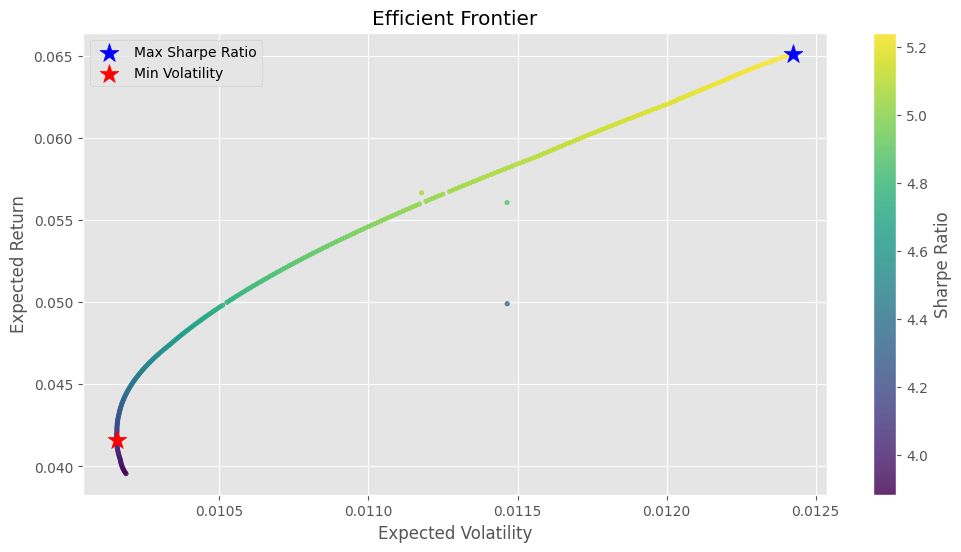


Risk Parity Optimal Weights:
VUG: 0.1408
MTUM: 0.1493
VTV: 0.1689
IYC: 0.1468
KBE: 0.1130
SPY: 0.1544
IWM: 0.1268


In [ ]:
if __name__ == "__main__":
    portfolio_returns = []

    for symbol in portfolio:
        etf = df[symbol].dropna() # 각 ETF의 수익률 데이터를 가져옴
        portfolio_returns.append(etf)

    # 포트폴리오의 수익률 데이터 프레임 생성 (공통 날짜 기준 조인 수행)
    returns = pd.concat(portfolio_returns, axis = 1, join = 'inner')  # 공통 날짜만 포함되도록 Inner Join
    returns.columns = portfolio  # 열 이름을 ETF 티커로 설정함

    # 1. MVO 포트폴리오 최적화
    mvo_weights = optimizeMVO(returns)
    print("MVO Optimal Weights:")

    for ticker, weight in zip(portfolio, mvo_weights):
        print(f"{ticker}: {weight:.4f}")

    plotEfficientFrontier(returns)

    # 2. RP 포트폴리오 최적화
    rp_weights = optimizeRiskParity(returns)
    print("\nRisk Parity Optimal Weights:")

    for ticker, weight in zip(portfolio, rp_weights):
        print(f"{ticker}: {weight:.4f}")

# VI. 최적화된 두 개의 포트폴리오 비율로 투자 백테스트 진행 -> v3 수정

### 타겟ETF를 사용함으로써 가격 데이터 고려를 고려가능, 비교적 정확하게 백테스팅 진행가능

### 벡테스팅 시점
- 1. 3개월 : 24/08 ~ 24/10
- 2. 6개월 : 24/05 ~ 24/10
- 3. 1년 : 23/10 ~ 24/10

### 백테스팅 조건
- 월말 리밸런싱 가정
- 매수 혹은 매도 당 발생하는 세금, 수수료, 시장충격 등 총 비용 퍼센테이지 = 약 0.4%(매도기준)로 설정

[*********************100%***********************]  7 of 7 completed
100%|██████████| 2/2 [00:00<00:00, 14.60it/s]



=== Last 3 Months Results ===
Stat                 MVO_Last 3 Months    RP_Last 3 Months
-------------------  -------------------  ------------------
Start                2024-07-31           2024-07-31
End                  2024-10-31           2024-10-31
Risk-free rate       0.00%                0.00%

Total Return         4.91%                5.06%
Daily Sharpe         1.04                 1.26
Daily Sortino        1.83                 2.06
CAGR                 20.95%               21.64%
Max Drawdown         -5.93%               -5.81%
Calmar Ratio         3.53                 3.73

MTD                  2.10%                -0.11%
3m                   4.91%                5.06%
6m                   -                    -
YTD                  4.91%                5.06%
1Y                   -                    -
3Y (ann.)            -                    -
5Y (ann.)            -                    -
10Y (ann.)           -                    -
Since Incep. (ann.)  20.95%              

100%|██████████| 2/2 [00:00<00:00,  8.46it/s]



=== Last 6 Months Results ===
Stat                 MVO_Last 6 Months    RP_Last 6 Months
-------------------  -------------------  ------------------
Start                2024-04-30           2024-04-30
End                  2024-10-31           2024-10-31
Risk-free rate       0.00%                0.00%

Total Return         17.59%               14.20%
Daily Sharpe         1.74                 1.86
Daily Sortino        3.13                 3.04
CAGR                 37.95%               30.17%
Max Drawdown         -9.58%               -9.17%
Calmar Ratio         3.96                 3.29

MTD                  2.10%                -0.11%
3m                   1.71%                2.89%
6m                   17.59%               14.20%
YTD                  17.59%               14.20%
1Y                   -                    -
3Y (ann.)            -                    -
5Y (ann.)            -                    -
10Y (ann.)           -                    -
Since Incep. (ann.)  37.95%       

100%|██████████| 2/2 [00:00<00:00,  5.39it/s]



=== Last 1 Year Results ===
Stat                 MVO_Last 1 Year    RP_Last 1 Year
-------------------  -----------------  ----------------
Start                2023-11-01         2023-11-01
End                  2024-10-31         2024-10-31
Risk-free rate       0.00%              0.00%

Total Return         40.73%             34.89%
Daily Sharpe         1.82               2.18
Daily Sortino        3.38               3.75
CAGR                 40.76%             34.92%
Max Drawdown         -9.58%             -9.18%
Calmar Ratio         4.26               3.81

MTD                  2.10%              -0.11%
3m                   1.71%              2.89%
6m                   19.77%             14.72%
YTD                  18.31%             18.67%
1Y                   -                  -
3Y (ann.)            -                  -
5Y (ann.)            -                  -
10Y (ann.)           -                  -
Since Incep. (ann.)  40.76%             34.92%

Daily Sharpe         1.82     

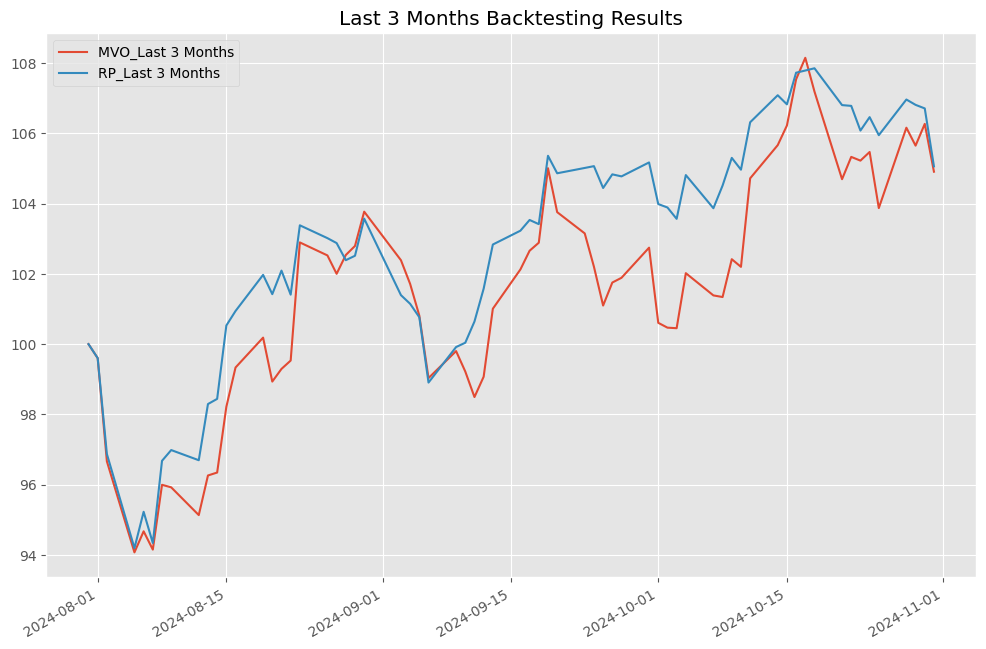

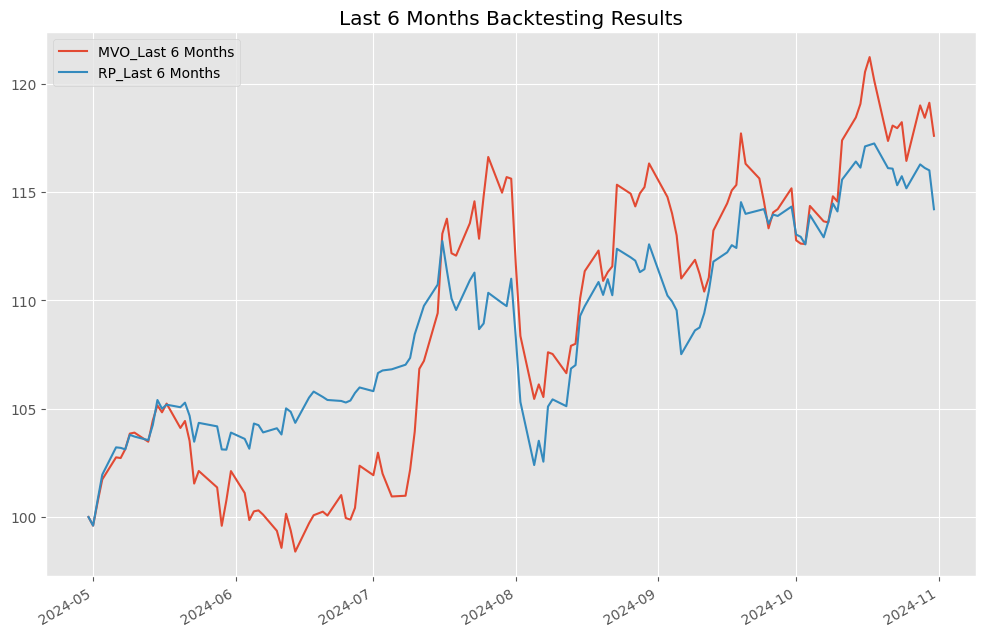

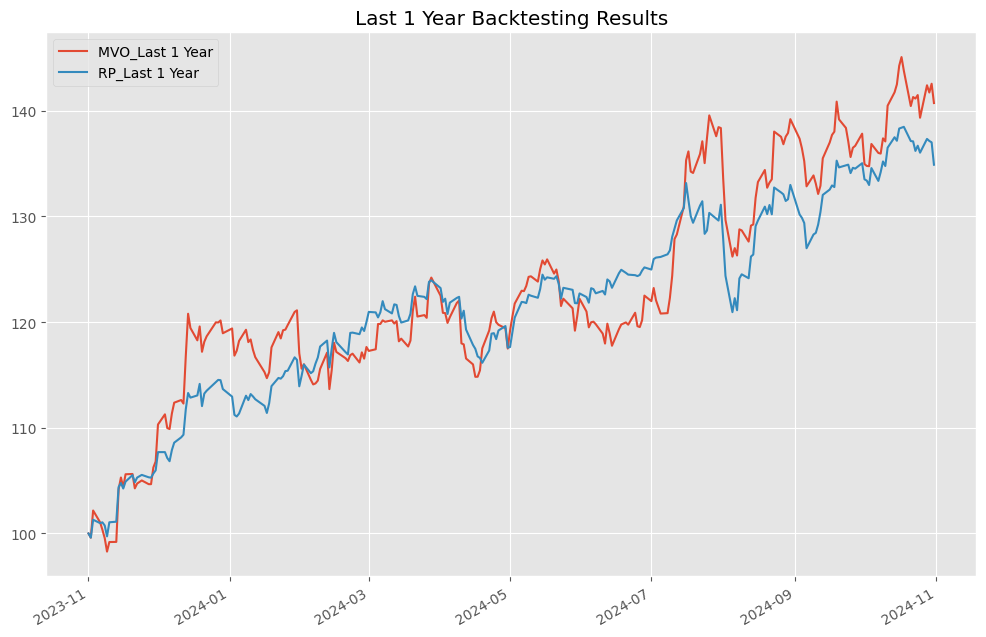

In [ ]:
if __name__ == "__main__":
    # 포트폴리오에 속한 각 ETF의 종가 데이터 불러오기
    data = yf.download(portfolio, start = "2023-11-01", end = "2024-11-01")["Close"].dropna()
    data.index = pd.to_datetime(data.index).strftime('%Y-%m-%d')
    data.columns = portfolio

    # 분석 기간 설정
    three_months = data.loc["2024-08-01":]  # 최근 3개월
    six_months = data.loc["2024-05-01":]  # 최근 6개월
    one_year = data.loc["2023-11-01":]  # 최근 1년

    # 각 기간 데이터 리스트
    periods = {
        "Last 3 Months": three_months,
        "Last 6 Months": six_months,
        "Last 1 Year": one_year
    }

    # 결과 저장용
    backtest_results = {}

    for period_name, period_data in periods.items():
        # 가격 데이터 재구성
        prices = data.loc[period_data.index]
        prices.index = pd.to_datetime(prices.index)

        # MVO 전략
        mvo_strategy = bt.Strategy(
            f"MVO_{period_name}",
            [
                bt.algos.SelectAll(),
                bt.algos.WeighSpecified(**{ticker : weight for ticker, weight in zip(portfolio, mvo_weights)}),
                bt.algos.RunMonthly(),
                bt.algos.Rebalance()
            ]
        )

        # RP 전략
        rp_strategy = bt.Strategy(
            f"RP_{period_name}",
            [
                bt.algos.SelectAll(),
                bt.algos.WeighSpecified(**{ticker : weight for ticker, weight in zip(portfolio, rp_weights)}),
                bt.algos.RunMonthly(),
                bt.algos.Rebalance()
            ]
        )

        # 백테스트 객체 생성
        mvo_backtest = bt.Backtest(mvo_strategy, prices, commissions = lambda q, p: abs(q) * p * 0.004)
        rp_backtest = bt.Backtest(rp_strategy, prices, commissions = lambda q, p: abs(q) * p * 0.004)

        # 백테스트 실행
        result = bt.run(mvo_backtest, rp_backtest)

        # 결과 저장
        backtest_results[period_name] = result

        # 결과 출력
        print(f"\n=== {period_name} Results ===")
        result.display()

        # 결과 그래프 생성
        result.plot(title = f"{period_name} Backtesting Results", figsize = (12, 8))

# VII. 백테스팅 결과 해석 : 1년 투자 시, MVO vs. RP 포트폴리오 누적수익률 그래프 분석

### 1. 투자 종목 및 포트폴리오 비율

MVO Optimal Weights:

**VTV: 0.7245
IYC: 0.0256
SPY: 0.2499**
(VUG: 0, KBE: 0, MTUM: 0, IWM: 0)

<br>

Risk Parity Optimal Weights:

**VUG: 0.1408
MTUM: 0.1493
VTV: 0.1689
IYC: 0.1468
KBE: 0.1130
SPY: 0.1544
IWM: 0.1268**

### 2. 종목 및 비중의 영향

MVO 구성:

- **VTV (Value ETF)**가 약 72.45%로 비중의 대부분을 차지, 안정적인 대형 가치주에 치중된 포트폴리오
- SPY (S&P 500 Index ETF) 24.99%로 시장 지수의 수익률을 보완
- IYC (Consumer Services ETF) 2.56%로 소비재 섹터의 소규모 투자
- 기술 성장주(VUG), 금융(KBE), 중소형주(IWM) 등은 포함되지 않음으로써 성장성보다 안정성에 집중
- 이 구성은 변동성을 줄이는 데 유리하지만, 상승장에서 초과 수익률 창출에는 다소 제한적일 수 있음

RP 구성:

- 다양한 ETF가 포함되어 분산 투자 효과를 극대화
- VUG(성장주), MTUM(모멘텀), SPY(지수), IYM(중소형주), KBE(금융) 등 섹터별로 리스크를 균등하게 배분
- 이는 특정 섹터에 치우치지 않아 하락장에서 더 안정적인 성과를 기대할 수 있는 구성

### 3. 그래프 해석

MVO (Mean-Variance Optimization):

- MVO 포트폴리오는 최대 샤프 비율을 목표로 하여 높은 수익성을 기대할 수 있도록 설계
- 그래프에서 초반에는 RP 전략을 상회하며 높은 수익률을 보였으나, 특정 시점(2024년 7~8월)을 기점으로 RP와 유사한 추세를 보이며 성과가 둔화
- 최종 누적 수익률: 약 40%에 해당하며, 초기 투자 대비 자산 가치가 140으로 증가

<br>

RP (Risk Parity):

- RP 포트폴리오는 리스크를 균등하게 배분하여 안정성을 중점적으로 설계된 전략
- 초반에는 MVO 대비 수익률이 낮았으나, 시장 변동성이 커진 시점에서도 더 안정적인 성과를 보임
- 최종 누적 수익률: 약 38%로 MVO와 유사한 결과를 보였으나, 더 낮은 변동성을 기록한 것으로 보임

### 4. 시장 상황 및 전략 성과

2024년 7~8월의 변동성:

- 시장 변동성이 커진 시점에서 MVO의 성과가 정체되거나 소폭 하락한 반면, RP는 더 안정적인 성과를 유지
- RP가 리스크를 균등하게 배분한 덕분에 단기적인 충격에 더 잘 대응했음을 보여줌

초반 MVO의 우세:

- MVO는 가치주(VTV)의 높은 비중으로 인해 상승장에서 빠르게 수익을 쌓을 수 있었음